# Categorization of inclusive MC and B_Y_SEP cut

This notebook investigates the categorization of the inclusive MC data (event type 23903000 for 2012).
It derives the best value for the B_Y_SEP cut to sperate Normalization from SIgnal

## Setting up the data and tools

In [1]:
# This is slow so we commen out and use the next cell insteasd that uses a cache dataframe instead
#%run load-rds-finalnobysepcut-2012-23903000-rs.ipynb

In [2]:
import pandas as pd
import ROOT
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
plt.rcParams["figure.figsize"] = (20,10)
from IPython.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

# Loading from extracted file until we can get the data
rdfsep = ROOT.RDataFrame("DecayTree", "temp.root")
dfsep = pd.DataFrame(rdfsep.Cache().AsNumpy())

Welcome to JupyROOT 6.28/00


In [3]:
!ls ../config/config.json

../config/config.json


In [4]:
def get_filenames(datatype, eventtype, sign):
    with open("../config/config.json") as f:
        import json
        conf = json.load(f)
        data_prefix=conf['DATA_DIR']
    polarities = [ "magdown", "magup" ]
    filenames = [ f"{data_prefix}/rds_final_{datatype}_{eventtype}_{polarity}_{sign}.root" 
                      for polarity in polarities ]
    return filenames

# bdd3pi
rdf11266009 = ROOT.RDataFrame("DecayTree", get_filenames("2012", "11266009", "None"))

# bsds3pi
rdf13266069 = ROOT.RDataFrame("DecayTree", get_filenames("2012", "13266069", "None"))

## CHecking the B mass histogram

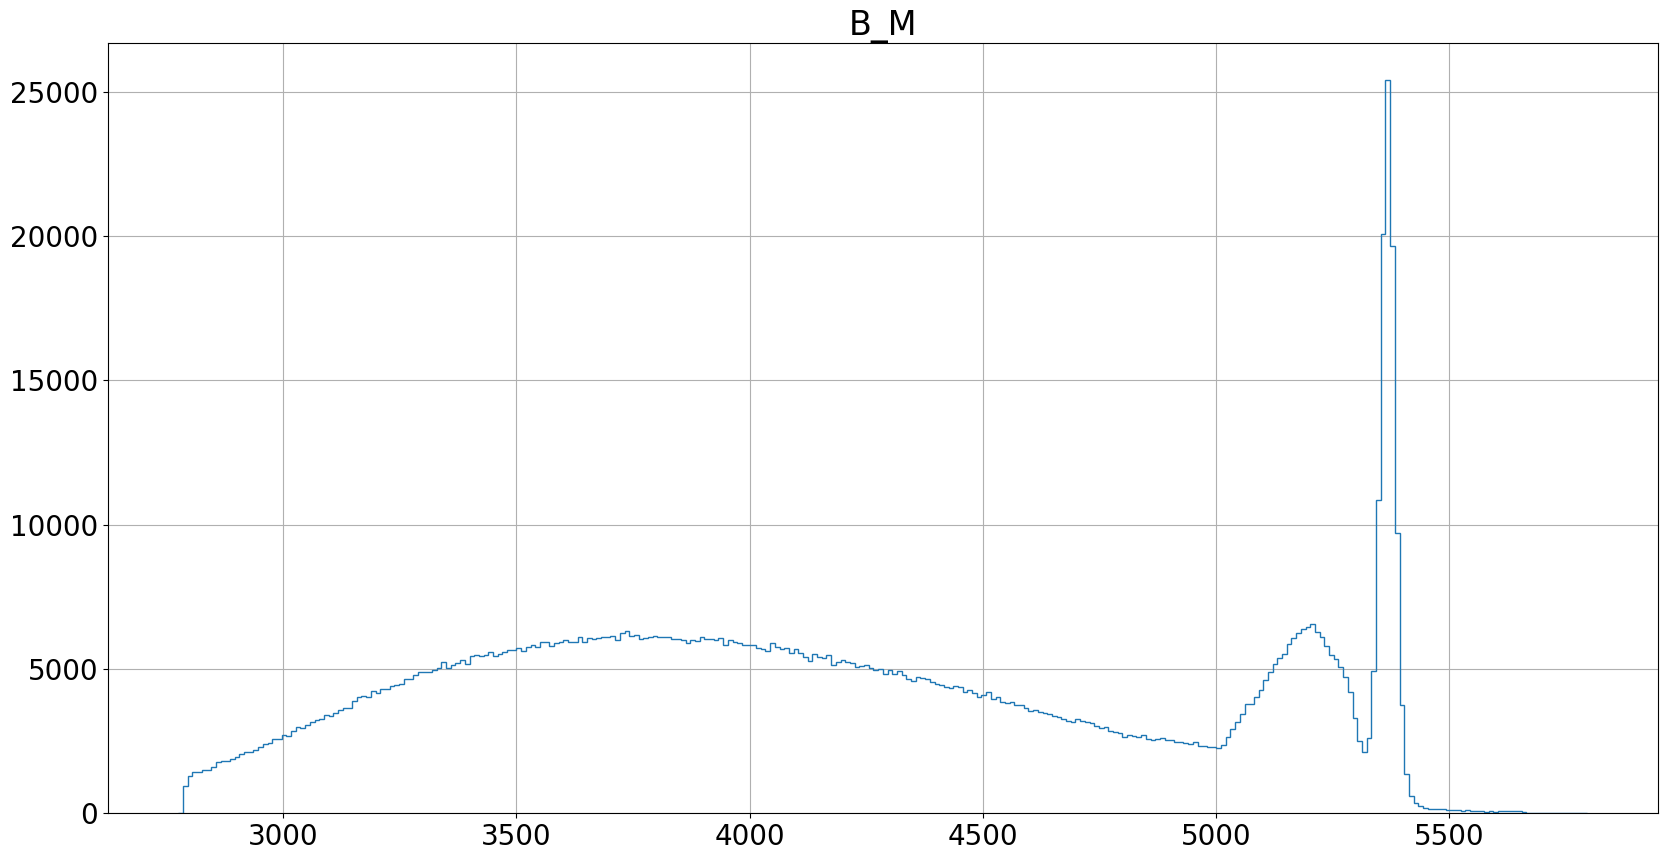

In [5]:
plt.rcParams.update({'font.size': 20})
dfsep.hist("B_M", bins=300, histtype='step')
plt.savefig("B_M_hist.png",  bbox_inches='tight');

In [6]:
dfsep.columns

Index(['B_M', 'B_Y_SEP', 'Xc_signal_Ypis_displaced_fromBs_fromTau', 'category',
       'fromY_from_B_vertex', 'simplified'],
      dtype='object')

In [7]:
import categories4 as f
#f.categories

In [8]:
f.detailed_to_pretty_category_mapping()

{'Xc_background': 'Bad Xc',
 'Xc_signal_Ypis_diffAncestorYXc': 'Combinatorial',
 'Xc_signal_Ypis_nomatch_Prompt': 'Normalization like',
 'Xc_signal_Ypis_nomatch_doubleCharm': 'Double Charm',
 'Xc_signal_Ypis_nomatch_charmStrange': 'Double Charm',
 'Xc_signal_Ypis_nomatch_Other': 'Combinatorial',
 'Xc_signal_Ypis_B_vertex_fromBs': 'Normalization like',
 'Xc_signal_Ypis_B_vertex_fromOtherB': 'Normalization like',
 'Xc_signal_Ypis_B_vertex_fromHc': 'Normalization like',
 'Xc_signal_Ypis_B_vertex_fromNone': 'Normalization like',
 'Xc_signal_Ypis_diffVertex_signal': 'Signal',
 'Xc_signal_Ypis_diffVertex_tauFromB': 'Signal',
 'Xc_signal_Ypis_diffVertex_normlike': 'Normalization like',
 'Xc_signal_Ypis_diffVertex_doubleCharm': 'Double Charm',
 'Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB': 'Double Charm',
 'Xc_signal_Ypis_diffVertex_doubleCharm_TwoFromB': 'Double Charm',
 'Xc_signal_Ypis_diffVertex_CharmStrange': 'Double Charm',
 'Xc_signal_Ypis_diffVertex_SomeFromPV': 'Combinatorial',
 'X

## Listing the categories

In [9]:
print(pd.DataFrame([ c for c in f.categories.keys() if "B_vertex" in c]).to_latex(index=None))

\begin{tabular}{l}
\toprule
                                  0 \\
\midrule
     Xc\_signal\_Ypis\_B\_vertex\_fromBs \\
 Xc\_signal\_Ypis\_B\_vertex\_fromOtherB \\
     Xc\_signal\_Ypis\_B\_vertex\_fromHc \\
   Xc\_signal\_Ypis\_B\_vertex\_fromNone \\
\bottomrule
\end{tabular}



/tmp/ipykernel_250067/30852556.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(pd.DataFrame([ c for c in f.categories.keys() if "B_vertex" in c]).to_latex(index=None))


In [10]:
with pd.option_context("max_colwidth", 1000):
    print(pd.DataFrame([ c for c in f.categories.keys() if "displaced" in c]).to_latex(index=None))

\begin{tabular}{l}
\toprule
                                                   0 \\
\midrule
              Xc\_signal\_Ypis\_displaced\_fromBs\_fromDs \\
              Xc\_signal\_Ypis\_displaced\_fromB0\_fromDp \\
              Xc\_signal\_Ypis\_displaced\_fromBp\_fromD0 \\
    Xc\_signal\_Ypis\_displaced\_fromLambdab\_fromLambdac \\
              Xc\_signal\_Ypis\_displaced\_fromBs\_fromDp \\
              Xc\_signal\_Ypis\_displaced\_fromBp\_fromDp \\
             Xc\_signal\_Ypis\_displaced\_fromBs\_fromTau \\
              Xc\_signal\_Ypis\_displaced\_fromB0\_fromD0 \\
              Xc\_signal\_Ypis\_displaced\_fromB0\_fromDs \\
              Xc\_signal\_Ypis\_displaced\_fromBs\_fromD0 \\
              Xc\_signal\_Ypis\_displaced\_fromBp\_fromDs \\
      Xc\_signal\_Ypis\_displaced\_fromBs\_fromDs\_fromTau \\
         Xc\_signal\_Ypis\_displaced\_fromLambdab\_fromDs \\
         Xc\_signal\_Ypis\_displaced\_fromLambdab\_fromDp \\
                    Xc\_signal\_Ypis\_displaced\_fro

/tmp/ipykernel_250067/2650052898.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(pd.DataFrame([ c for c in f.categories.keys() if "displaced" in c]).to_latex(index=None))


In [11]:
with pd.option_context("max_colwidth", 1000):
    df = pd.DataFrame(list(f.detailed_to_pretty_category_mapping().items()), 
                      columns = [ "Category", "Simplified category"])
    print(df.to_latex(index=None))

\begin{tabular}{ll}
\toprule
                                            Category & Simplified category \\
\midrule
                                       Xc\_background &              Bad Xc \\
                      Xc\_signal\_Ypis\_diffAncestorYXc &       Combinatorial \\
                       Xc\_signal\_Ypis\_nomatch\_Prompt &  Normalization like \\
                  Xc\_signal\_Ypis\_nomatch\_doubleCharm &        Double Charm \\
                 Xc\_signal\_Ypis\_nomatch\_charmStrange &        Double Charm \\
                        Xc\_signal\_Ypis\_nomatch\_Other &       Combinatorial \\
                      Xc\_signal\_Ypis\_B\_vertex\_fromBs &  Normalization like \\
                  Xc\_signal\_Ypis\_B\_vertex\_fromOtherB &  Normalization like \\
                      Xc\_signal\_Ypis\_B\_vertex\_fromHc &  Normalization like \\
                    Xc\_signal\_Ypis\_B\_vertex\_fromNone &  Normalization like \\
                    Xc\_signal\_Ypis\_diffVertex\_signal &      

/tmp/ipykernel_250067/4013543734.py:4: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df.to_latex(index=None))


In [12]:
with pd.option_context("max_colwidth", 1000):
    df = pd.DataFrame(list(f.pretty_bkg_categories()), 
                      columns = [ "Simplified category"])
    print(df.sort_values(by="Simplified category").to_latex(index=None))

\begin{tabular}{l}
\toprule
Simplified category \\
\midrule
             Bad Xc \\
      Combinatorial \\
       Double Charm \\
 Normalization like \\
    Other displaced \\
             Signal \\
     Tau from charm \\
      Uncategorized \\
\bottomrule
\end{tabular}



/tmp/ipykernel_250067/987408660.py:4: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df.sort_values(by="Simplified category").to_latex(index=None))


In [13]:
sorted(f.simplified_categories_keys)

['WithfromPV',
 'Xc_background',
 'Xc_signal_Ypis_diffAncestorYXc',
 'Xc_signal_Ypis_nomatch_Other',
 'doubleCharm',
 'normlike',
 'otherDisplaced',
 'signal',
 'tauFromCharm']

In [14]:
# %time
# rdf = f.add_categories_and_filter(rdf)

In [15]:
def mygroupby(d, groupbycols):
    g = d.groupby(groupbycols).size().reset_index(name='count').sort_values([ 'count'], ascending=False).reset_index(drop=True)
    g["Percentage"] = g.apply(lambda row: 100 * row["count"]/d.shape[0], axis=1)
    g["cumulative %"] = g["Percentage"].cumsum(axis = 0)
    return g

In [16]:
rdfsep.Count().GetValue()

1207697

## Basic statistics

In [17]:
# %%time
# filename = "categorization_df.pkl"
# if os.path.exists(filename):
#     print("You can reload pkl file")
#     df = pd.read_pickle(filename)
# else:
#     df = pd.DataFrame(rdf.Cache(list(f.categories.keys()) 
#                                             + [ "B_Y_SEP", "Xc_Y_SEP", "Y_ENDVERTEX_CHI2", "totCandidates", "Y_MM", "fromY_maxVtxZsep", 
#                                              "fromY_sameVertex", "Y_fromBVertex", "B_MM", "commonAncestor_YXc",
#                                              "Y_fromTau",
#                                              "Y_fromDp",
#                                              "Y_fromD0",
#                                              "Y_fromDs",
#                                              "Y_fromLambdac",
#                                              "Y_fromBs",
#                                              "Y_fromHc",
#                                              "Y_fromOtherB",
#                                               "category", "simplified"]).AsNumpy())
#     df['key'] = df.apply(f.categorize_key, axis=1)
#     mapping = f.detailed_to_simplified_category_mapping.copy()
#     mapping["NA"] = "NA"
#     df['simplified_key'] = df.apply(lambda row: mapping[row["key"]], axis=1)
#     df.to_pickle("categorization_df.pkl")

In [18]:
#dfsep['simplified_key'] = dfsep.apply(lambda row: f.simplified_categories_map[row["simplified"]], axis=1)
dfsep['simplified_key'] = dfsep.apply(lambda row: f.pretty_categories_map[row["simplified"]], axis=1)

In [19]:
dfsep['key'] = dfsep.apply(lambda row: f.categories_map[row["category"]], axis=1)

In [20]:
dfsep

,B_M,B_Y_SEP,Xc_signal_Ypis_displaced_fromBs_fromTau,category,fromY_from_B_vertex,simplified,simplified_key,key
0,3549.868167,-42.580564,False,0,False,1001,Bad Xc,Xc_background
1,3359.746270,-0.395281,False,0,False,1001,Bad Xc,Xc_background
2,5365.929742,-0.689973,False,2,True,1005,Normalization like,Xc_signal_Ypis_B_vertex_fromBs
3,3951.645480,-4.062585,False,14,False,1004,Double Charm,Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB
4,3319.233948,-25.553933,False,0,False,1001,Bad Xc,Xc_background
...,...,...,...,...,...,...,...,...
1207692,3400.800053,-5.197422,False,7,False,1004,Double Charm,Xc_signal_Ypis_nomatch_doubleCharm
1207693,3677.808315,-1.025608,False,2,True,1005,Normalization like,Xc_signal_Ypis_B_vertex_fromBs
1207694,3487.951691,2.499871,False,2,True,1005,Normalization like,Xc_signal_Ypis_B_vertex_fromBs
1207695,2937.090737,1.080720,False,12,False,1005,Normalization like,Xc_signal_Ypis_diffVertex_normlike


# Checking the reconstructed B mass

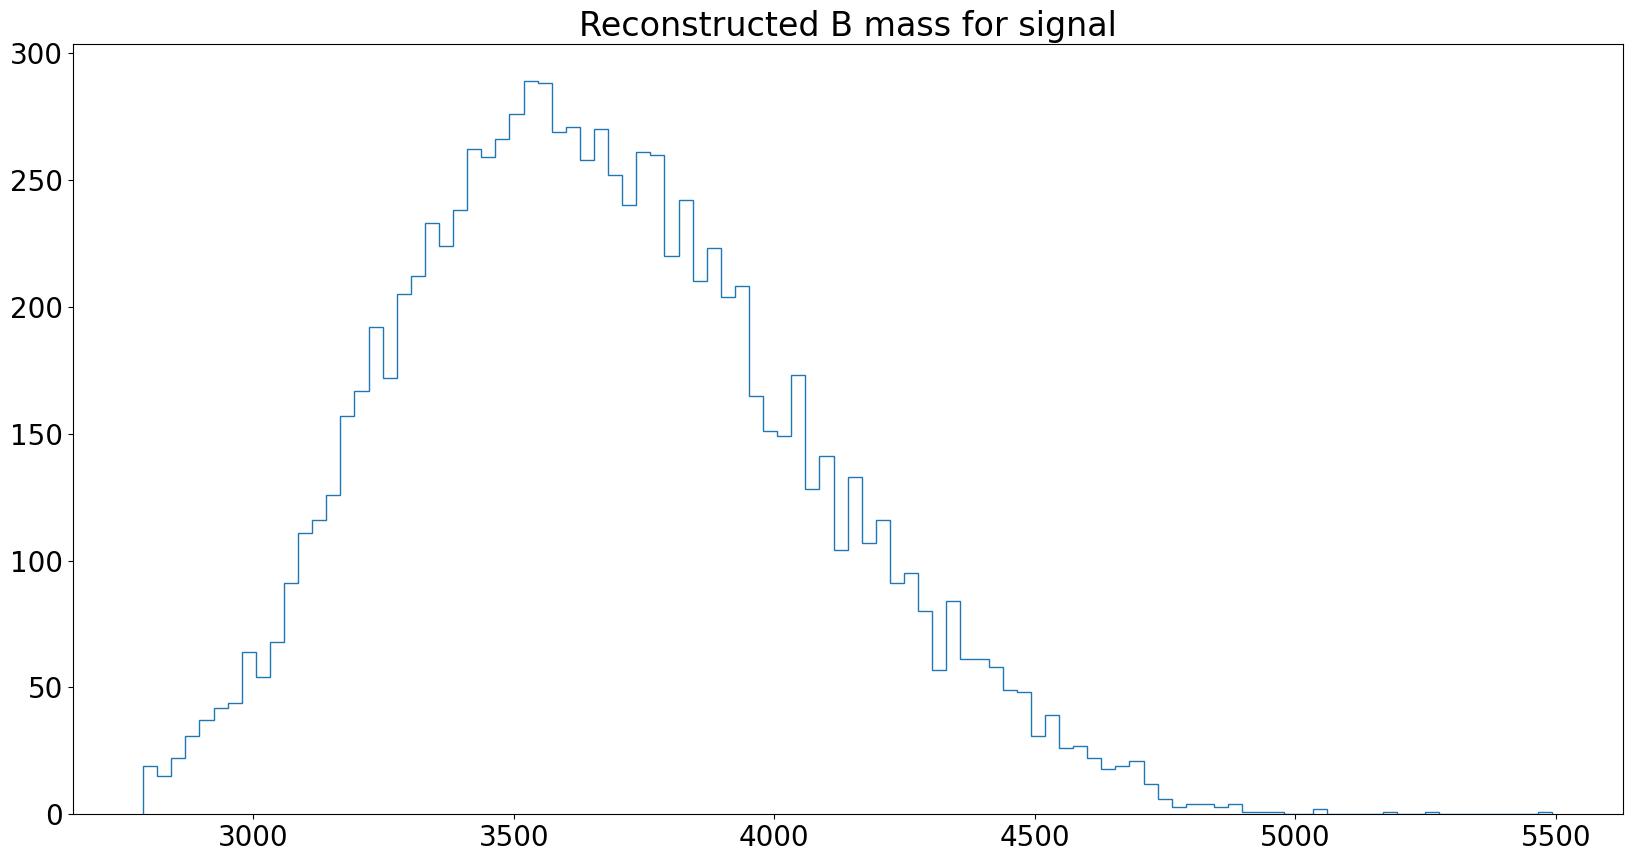

In [21]:
dfsep.query("simplified_key == 'Signal'")['B_M'].hist(bins=100, histtype='step')
plt.grid(False)
plt.title("Reconstructed B mass for signal")
plt.savefig("B_m_signal.png")

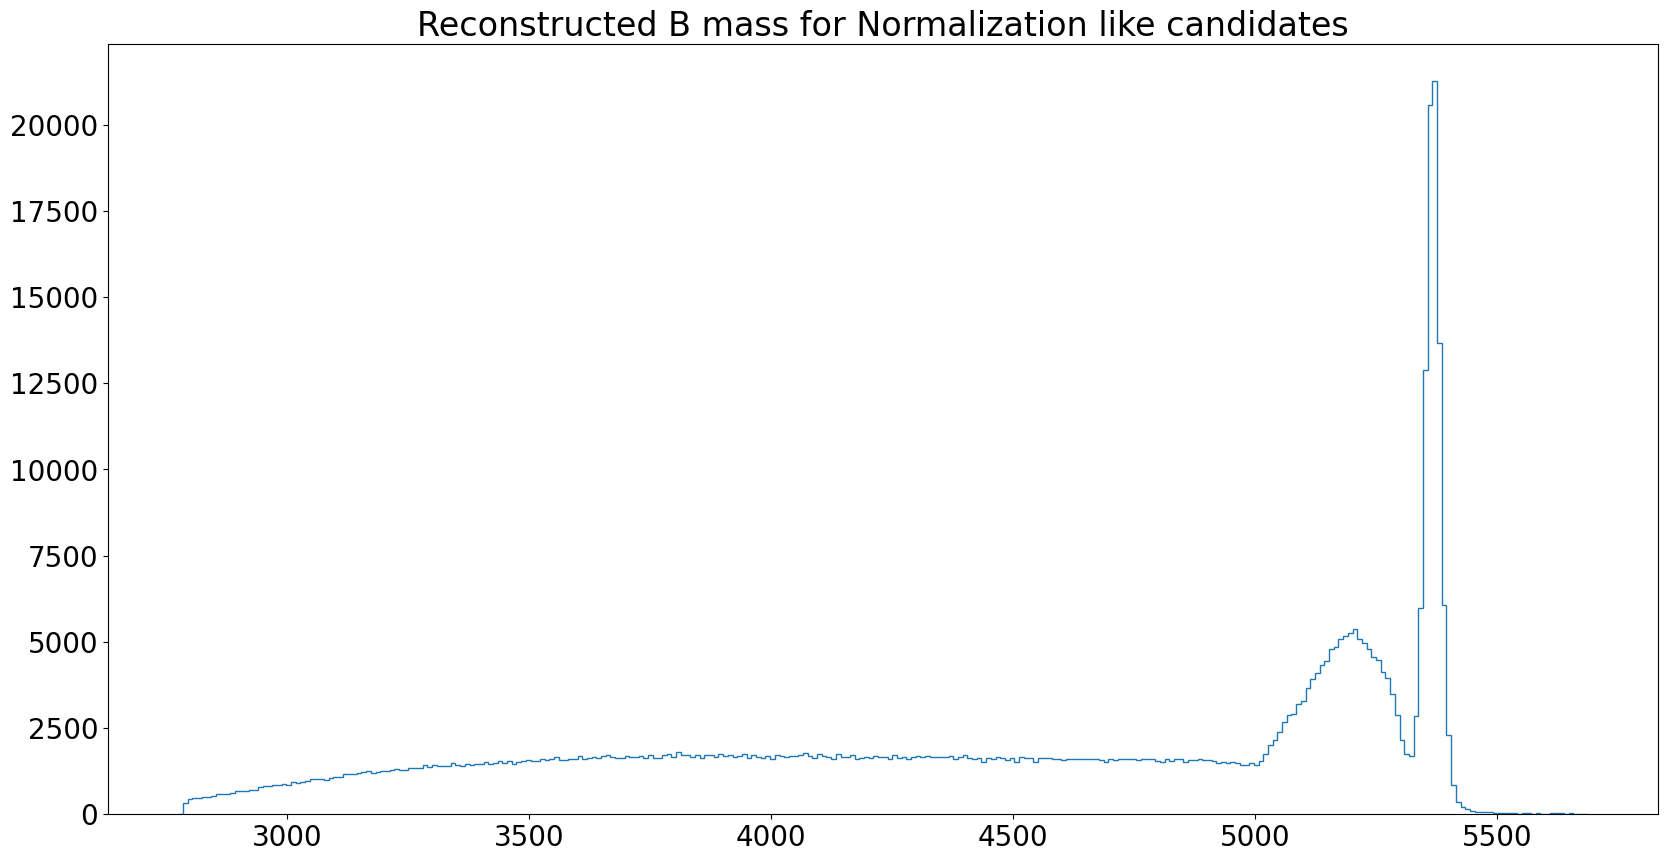

In [22]:
dfsep.query("simplified_key == 'Normalization like'")['B_M'].hist(bins=300, histtype='step')
plt.grid(False)
plt.title("Reconstructed B mass for Normalization like candidates")
plt.savefig("B_m_normlike.png")

In [23]:
df11266009 = pd.DataFrame(rdf11266009.Cache(["B_M"]).AsNumpy())

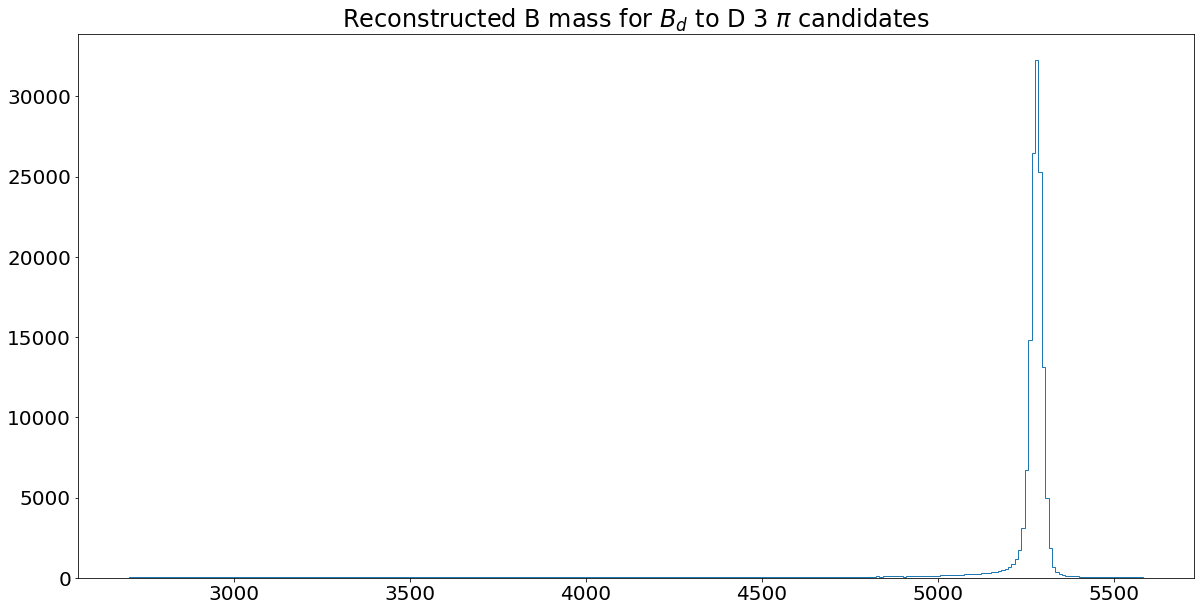

In [24]:
df11266009.hist(bins=300, histtype='step')
plt.grid(False)
plt.title("Reconstructed B mass for $B_d$ to D 3 $\pi$ candidates")
plt.savefig("B_m_bdd3pi.png")

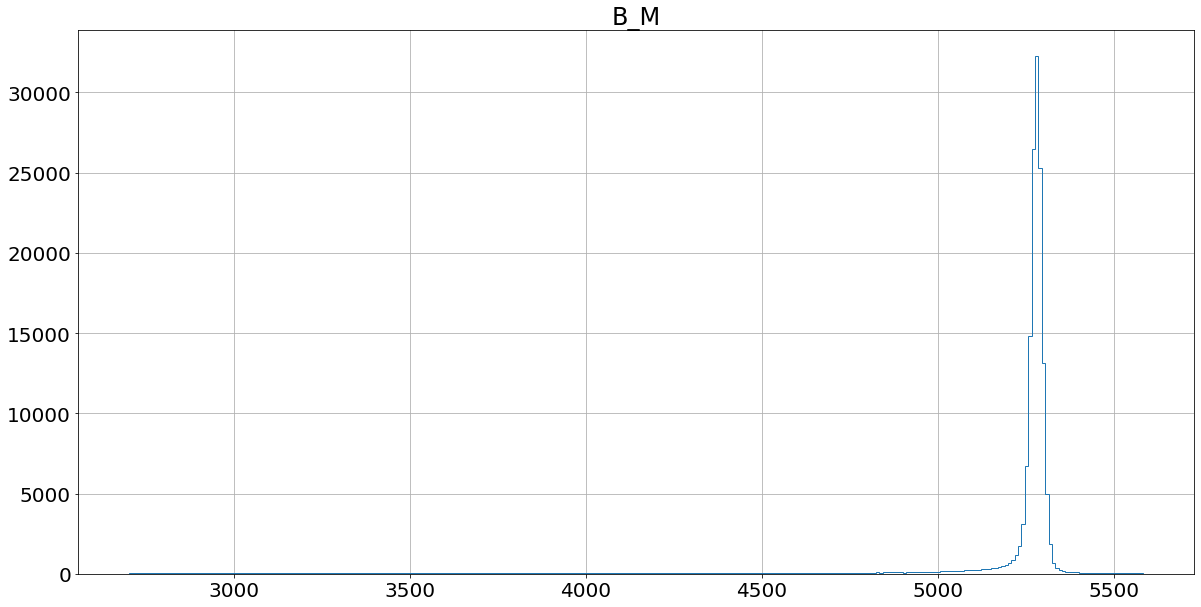

In [25]:
df11266009.hist(bins=300, histtype='step')
df13266069 = pd.DataFrame(rdf13266069.Cache(["B_M"]).AsNumpy())

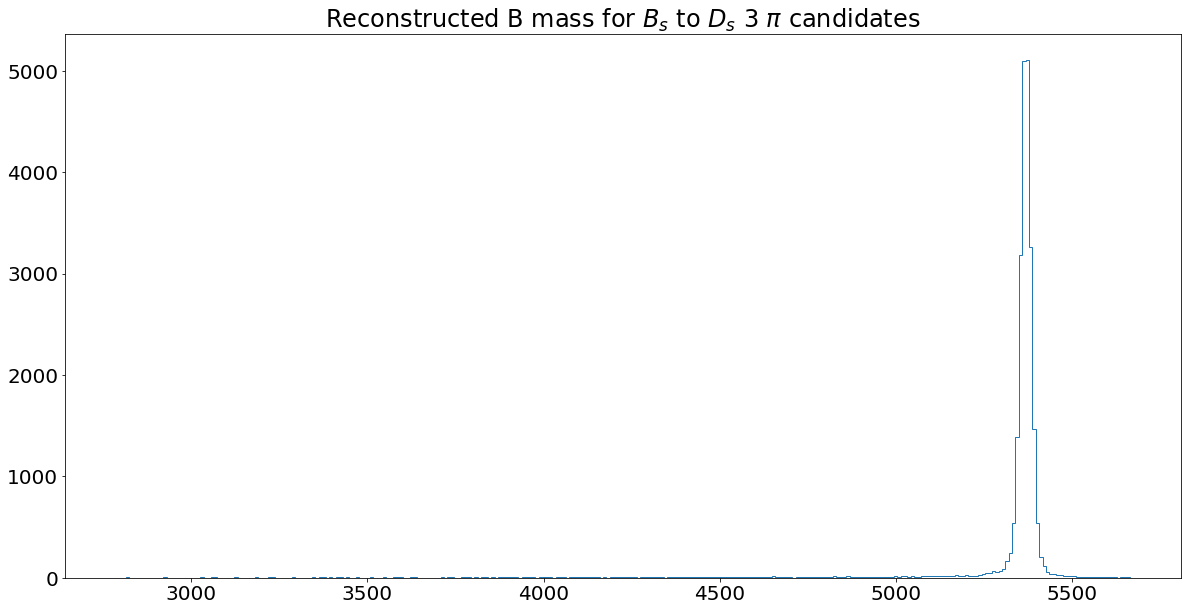

In [26]:
df13266069.hist(bins=300, histtype='step')
plt.grid(False)
plt.title("Reconstructed B mass for $B_s$ to $D_s$ 3 $\pi$ candidates")
plt.savefig("B_m_bsds3pi.png")

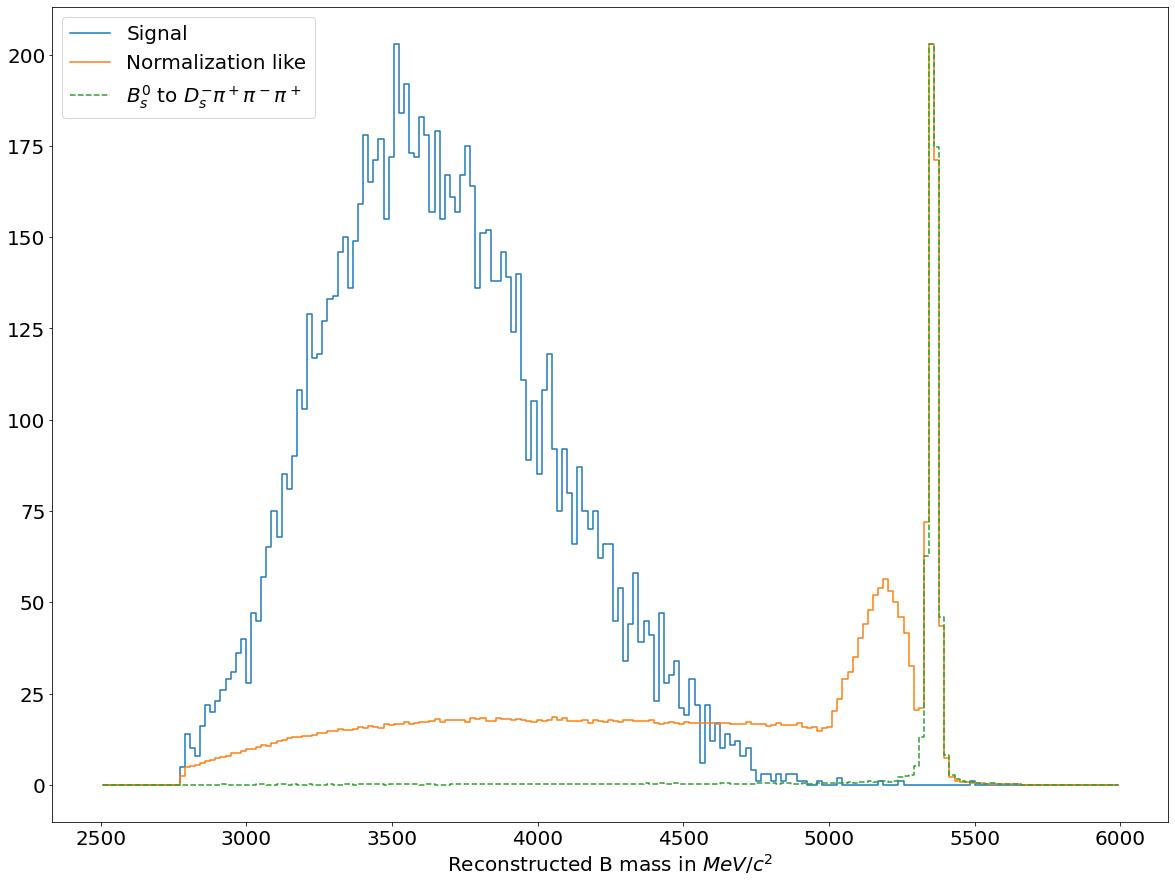

In [27]:
plt.rcParams["figure.figsize"] = (20,15)
plt.grid(False)
bn=200
rg=[2500, 6000]
normalize = False
signal, bin_edges = np.histogram(dfsep.query("simplified_key == 'Signal'")['B_M'], bins=bn, range=rg,  density=normalize, )
normlike, bin_edges = np.histogram(dfsep.query("simplified_key == 'Normalization like'")['B_M'], bins=bn, range=rg,  density=normalize,)
bsds3pi, bin_edges = np.histogram(df13266069['B_M'], bins=bn, range=rg,  density=normalize,)
bdd3pi, bin_edges = np.histogram(df11266009['B_M'], bins=bn, range=rg,  density=normalize, )
bins = (bin_edges[1:] + bin_edges[:-1]) / 2

normlike = normlike * max(signal) / max(normlike)
bsds3pi = bsds3pi * max(signal) / max(bsds3pi)
bdd3pi = bdd3pi *  max(signal) / max(bdd3pi)

# equiv to plt.hist
#plt.bar(bins, signal, label='Signal', width=np.diff(bin_edges), align='edge')

plt.step(bins, signal, label='Signal')
plt.step(bins, normlike, label='Normalization like')
plt.step(bins, bsds3pi, label='$B_s^0$ to $D_s^{-}\pi^+\pi^-\pi^+$', linestyle='dashed',)
#plt.step(bins, bdd3pi, label='$B_d^0$ to $D^-\pi^+\pi^-\pi^+$')

# plt.hist(dfsep.query("simplified_key == 'Signal'")['B_M'], bins=bn, range=rg, histtype='step', density=normalize, label='Signal')
# plt.hist(df13266069['B_M'], bins=bn, range=rg, histtype='step', density=normalize, label='$B_s^0$ to $D_s^{-}\pi^+\pi^-\pi^+$')
# plt.hist(df11266009['B_M'], bins=bn, range=rg, histtype='step', density=normalize, label='$B_d^0$ to $D^-\pi^+\pi^-\pi^+$')
plt.legend()
#plt.title("Reconstructed B mass histogram for signal and normalization channel (normalized)")
#plt.yscale("log")
plt.xlabel("Reconstructed B mass in $MeV/c^2$")
plt.savefig("B_M_signal_norm.png");

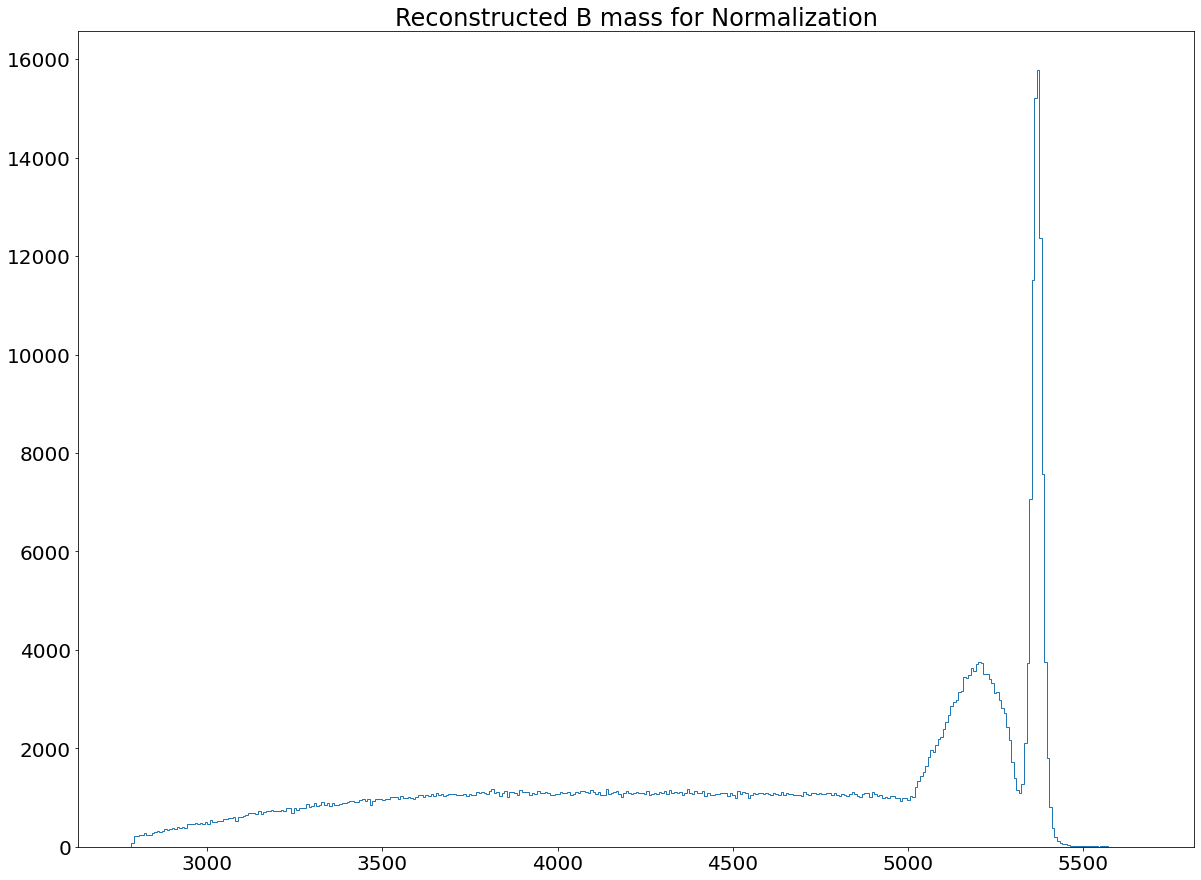

In [28]:
dfsep.query("key == 'Xc_signal_Ypis_B_vertex_fromBs'")['B_M'].hist(bins=400, histtype='step')
plt.grid(False)
plt.title("Reconstructed B mass for Normalization")
plt.savefig("B_m_norm.png")

In [29]:
#gmt5000 = pd.DataFrame(
#dfsep.query("B_M > 5000").groupby("key").count()["key"]#).rename(columns={"key":"count"})
pd.DataFrame(dfsep.query("B_M > 5000").groupby("key").count()['category']).rename(columns={"category":"count"}).sort_values([ 'count'], ascending=False)

,count
key,
Xc_signal_Ypis_B_vertex_fromBs,196309
Xc_background,25811
Xc_signal_Ypis_nomatch_Prompt,10701
Xc_signal_Ypis_displaced_fromBs_fromDs,6208
Xc_signal_Ypis_nomatch_doubleCharm,1872
Xc_signal_Ypis_displaced_fromB0_fromDp,1785
Xc_signal_Ypis_diffVertex_normlike,1417
Xc_signal_Ypis_displaced_fromLambdab_fromLambdac,993
Xc_signal_Ypis_diffAncestorYXc,874


## Grouping low ranking entries in the table

In [23]:
g = pd.DataFrame(dfsep.groupby("key").count()["category"]).rename(columns={"category":"count"})

In [24]:
g["Category"] = g.apply(lambda row: row.name if row["count"] > 400 else "others", axis=1)

In [25]:
g2 = g.groupby("Category").sum()#('count')#.sort_values([ 'count'], ascending=False).reset_index(drop=True)

In [26]:
g2 = g2.sort_values([ 'count'], ascending=False)

In [27]:
total = g2.sum()["count"]
g2["Percentage"] = g2.apply(lambda row: 100 * row["count"]/total, axis=1)
g2["cumulative %"] = g2["Percentage"].cumsum(axis = 0)

In [28]:
with pd.option_context("max_colwidth", 1000, 'display.precision', 2):
    print(g2[['count', 'Percentage']].to_latex())

\begin{tabular}{lrr}
\toprule
{} &   count &  Percentage \\
Category                                         &         &             \\
\midrule
Xc\_signal\_Ypis\_B\_vertex\_fromBs                   &  481611 &       39.88 \\
Xc\_background                                    &  183031 &       15.16 \\
Xc\_signal\_Ypis\_diffVertex\_doubleCharm\_OneFromB   &  130954 &       10.84 \\
Xc\_signal\_Ypis\_displaced\_fromBs\_fromDs           &   84307 &        6.98 \\
Xc\_signal\_Ypis\_displaced\_fromB0\_fromDp           &   66975 &        5.55 \\
Xc\_signal\_Ypis\_nomatch\_doubleCharm               &   40822 &        3.38 \\
Xc\_signal\_Ypis\_nomatch\_Prompt                    &   37559 &        3.11 \\
Xc\_signal\_Ypis\_displaced\_fromBp\_fromD0           &   30159 &        2.50 \\
Xc\_signal\_Ypis\_displaced\_fromLambdab\_fromLambdac &   23554 &        1.95 \\
Xc\_signal\_Ypis\_diffVertex\_doubleCharm\_TwoFromB   &   23275 &        1.93 \\
Xc\_signal\_Ypis\_displaced\_fromBs\_fromDp        

/tmp/ipykernel_250067/961080659.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(g2[['count', 'Percentage']].to_latex())


In [29]:
print(g2[['count', 'Percentage']].to_markdown())

| Category                                         |   count |   Percentage |
|:-------------------------------------------------|--------:|-------------:|
| Xc_signal_Ypis_B_vertex_fromBs                   |  481611 |   39.8785    |
| Xc_background                                    |  183031 |   15.1554    |
| Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB   |  130954 |   10.8433    |
| Xc_signal_Ypis_displaced_fromBs_fromDs           |   84307 |    6.98081   |
| Xc_signal_Ypis_displaced_fromB0_fromDp           |   66975 |    5.54568   |
| Xc_signal_Ypis_nomatch_doubleCharm               |   40822 |    3.38015   |
| Xc_signal_Ypis_nomatch_Prompt                    |   37559 |    3.10997   |
| Xc_signal_Ypis_displaced_fromBp_fromD0           |   30159 |    2.49723   |
| Xc_signal_Ypis_displaced_fromLambdab_fromLambdac |   23554 |    1.95032   |
| Xc_signal_Ypis_diffVertex_doubleCharm_TwoFromB   |   23275 |    1.92722   |
| Xc_signal_Ypis_displaced_fromBs_fromDp           |   16769 |  

In [30]:
gs = mygroupby(dfsep, "simplified_key")

In [31]:
gs

,simplified_key,count,Percentage,cumulative %
0,Normalization like,541243,44.816125,44.816125
1,Double Charm,464918,38.496245,83.312371
2,Bad Xc,183031,15.155374,98.467745
3,Signal,9966,0.825207,99.292952
4,Combinatorial,6657,0.551214,99.844166
5,Tau from charm,1441,0.119318,99.963484
6,Other displaced,345,0.028567,99.992051
7,Uncategorized,96,0.007949,100.000000


In [32]:
with pd.option_context("max_colwidth", 1000, 'display.precision', 2, 'float_format',  '${:,.2f}'.format):
    print(gs[['simplified_key', 'count', 'Percentage']].to_latex(index=None))

\begin{tabular}{lrr}
\toprule
     simplified\_key &   count &  Percentage \\
\midrule
 Normalization like &  541243 &      \$44.82 \\
       Double Charm &  464918 &      \$38.50 \\
             Bad Xc &  183031 &      \$15.16 \\
             Signal &    9966 &       \$0.83 \\
      Combinatorial &    6657 &       \$0.55 \\
     Tau from charm &    1441 &       \$0.12 \\
    Other displaced &     345 &       \$0.03 \\
      Uncategorized &      96 &       \$0.01 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_250067/3549017427.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(gs[['simplified_key', 'count', 'Percentage']].to_latex(index=None))


In [33]:
print(gs[['simplified_key', 'count', 'Percentage']].to_markdown(index=None))

| simplified_key     |   count |   Percentage |
|:-------------------|--------:|-------------:|
| Normalization like |  541243 |  44.8161     |
| Double Charm       |  464918 |  38.4962     |
| Bad Xc             |  183031 |  15.1554     |
| Signal             |    9966 |   0.825207   |
| Combinatorial      |    6657 |   0.551214   |
| Tau from charm     |    1441 |   0.119318   |
| Other displaced    |     345 |   0.0285668  |
| Uncategorized      |      96 |   0.00794901 |


In [34]:
gs["Category"] = gs.apply(lambda row: row['simplified_key'] if row["count"] > 400 else "others", axis=1)
gs2 = gs.groupby("Category").sum()
gs2 = gs2.sort_values([ 'count'], ascending=False)
total = gs2.sum()["count"]
gs2["Percentage"] = gs2.apply(lambda row: 100 * row["count"]/total, axis=1)
gs2["cumulative %"] = gs2["Percentage"].cumsum(axis = 0)

/tmp/ipykernel_250067/201763320.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  gs2 = gs.groupby("Category").sum()


In [35]:
gs2

,count,Percentage,cumulative %
Category,,,
Normalization like,541243,44.816125,44.816125
Double Charm,464918,38.496245,83.312371
Bad Xc,183031,15.155374,98.467745
Signal,9966,0.825207,99.292952
Combinatorial,6657,0.551214,99.844166
Tau from charm,1441,0.119318,99.963484
others,441,0.036516,100.000000


In [36]:
with pd.option_context("max_colwidth", 1000, 'display.precision', 2, 'float_format',  '{:,.2f}'.format):
    print(gs2[['count', 'Percentage']].to_latex())

\begin{tabular}{lrr}
\toprule
{} &   count &  Percentage \\
Category           &         &             \\
\midrule
Normalization like &  541243 &       44.82 \\
Double Charm       &  464918 &       38.50 \\
Bad Xc             &  183031 &       15.16 \\
Signal             &    9966 &        0.83 \\
Combinatorial      &    6657 &        0.55 \\
Tau from charm     &    1441 &        0.12 \\
others             &     441 &        0.04 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_250067/3046124411.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(gs2[['count', 'Percentage']].to_latex())


# Checking with cut on B mass

In [37]:
g5000 = pd.DataFrame(dfsep.query("B_M < 5000").groupby("key").count()["category"]).rename(columns={"category":"count"})

In [38]:
g5000["Category"] = g.apply(lambda row: row.name if row["count"] > 400 else "others", axis=1)

In [39]:
g5000_2 = g5000.groupby("Category").sum()#('count')#.sort_values([ 'count'], ascending=False).reset_index(drop=True)

In [40]:
g5000_2 = g5000_2.sort_values([ 'count'], ascending=False)

In [41]:
total = g5000_2.sum()["count"]
g5000_2["Percentage"] = g5000_2.apply(lambda row: 100 * row["count"]/total, axis=1)
g5000_2["cumulative %"] = g5000_2["Percentage"].cumsum(axis = 0)

In [42]:
with pd.option_context("max_colwidth", 1000, 'display.precision', 2):
    print(g5000_2[['count', 'Percentage']].to_latex())

\begin{tabular}{lrr}
\toprule
{} &   count &  Percentage \\
Category                                         &         &             \\
\midrule
Xc\_signal\_Ypis\_B\_vertex\_fromBs                   &  285302 &       29.75 \\
Xc\_background                                    &  157220 &       16.39 \\
Xc\_signal\_Ypis\_diffVertex\_doubleCharm\_OneFromB   &  130226 &       13.58 \\
Xc\_signal\_Ypis\_displaced\_fromBs\_fromDs           &   78099 &        8.14 \\
Xc\_signal\_Ypis\_displaced\_fromB0\_fromDp           &   65190 &        6.80 \\
Xc\_signal\_Ypis\_nomatch\_doubleCharm               &   38950 &        4.06 \\
Xc\_signal\_Ypis\_displaced\_fromBp\_fromD0           &   30025 &        3.13 \\
Xc\_signal\_Ypis\_nomatch\_Prompt                    &   26858 &        2.80 \\
Xc\_signal\_Ypis\_diffVertex\_doubleCharm\_TwoFromB   &   23271 &        2.43 \\
Xc\_signal\_Ypis\_displaced\_fromLambdab\_fromLambdac &   22561 &        2.35 \\
Xc\_signal\_Ypis\_displaced\_fromBs\_fromDp        

/tmp/ipykernel_250067/4103565355.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(g5000_2[['count', 'Percentage']].to_latex())


In [43]:
print(g5000_2[['count', 'Percentage']].to_markdown())

| Category                                         |   count |   Percentage |
|:-------------------------------------------------|--------:|-------------:|
| Xc_signal_Ypis_B_vertex_fromBs                   |  285302 |   29.746     |
| Xc_background                                    |  157220 |   16.392     |
| Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB   |  130226 |   13.5775    |
| Xc_signal_Ypis_displaced_fromBs_fromDs           |   78099 |    8.14271   |
| Xc_signal_Ypis_displaced_fromB0_fromDp           |   65190 |    6.7968    |
| Xc_signal_Ypis_nomatch_doubleCharm               |   38950 |    4.06098   |
| Xc_signal_Ypis_displaced_fromBp_fromD0           |   30025 |    3.13045   |
| Xc_signal_Ypis_nomatch_Prompt                    |   26858 |    2.80025   |
| Xc_signal_Ypis_diffVertex_doubleCharm_TwoFromB   |   23271 |    2.42627   |
| Xc_signal_Ypis_displaced_fromLambdab_fromLambdac |   22561 |    2.35224   |
| Xc_signal_Ypis_displaced_fromBs_fromDp           |   16615 |  

In [44]:
gs5000 = mygroupby(dfsep.query("B_M < 5000"), "simplified_key")

In [45]:
gs5000

,simplified_key,count,Percentage,cumulative %
0,Double Charm,452226,47.149703,47.149703
1,Normalization like,332365,34.652830,81.802533
2,Bad Xc,157220,16.391973,98.194506
3,Signal,9961,1.038548,99.233053
4,Combinatorial,5503,0.573750,99.806804
5,Tau from charm,1438,0.149928,99.956732
6,Other displaced,319,0.033259,99.989991
7,Uncategorized,96,0.010009,100.000000


In [46]:
with pd.option_context("max_colwidth", 1000, 'display.precision', 2, 'float_format',  '${:,.2f}'.format):
    print(gs5000[['simplified_key', 'count', 'Percentage']].to_latex(index=None))

\begin{tabular}{lrr}
\toprule
     simplified\_key &   count &  Percentage \\
\midrule
       Double Charm &  452226 &      \$47.15 \\
 Normalization like &  332365 &      \$34.65 \\
             Bad Xc &  157220 &      \$16.39 \\
             Signal &    9961 &       \$1.04 \\
      Combinatorial &    5503 &       \$0.57 \\
     Tau from charm &    1438 &       \$0.15 \\
    Other displaced &     319 &       \$0.03 \\
      Uncategorized &      96 &       \$0.01 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_250067/973680244.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(gs5000[['simplified_key', 'count', 'Percentage']].to_latex(index=None))


In [47]:
print(gs5000[['simplified_key', 'count', 'Percentage']].to_markdown(index=None))

| simplified_key     |   count |   Percentage |
|:-------------------|--------:|-------------:|
| Double Charm       |  452226 |   47.1497    |
| Normalization like |  332365 |   34.6528    |
| Bad Xc             |  157220 |   16.392     |
| Signal             |    9961 |    1.03855   |
| Combinatorial      |    5503 |    0.57375   |
| Tau from charm     |    1438 |    0.149928  |
| Other displaced    |     319 |    0.0332594 |
| Uncategorized      |      96 |    0.0100091 |


In [48]:
gs5000["Category"] = gs5000.apply(lambda row: row['simplified_key'] if row["count"] > 400 else "others", axis=1)
gs5000_2 = gs5000.groupby("Category").sum()
gs5000_2 = gs5000_2.sort_values([ 'count'], ascending=False)
total = gs5000_2.sum()["count"]
gs5000_2["Percentage"] = gs5000_2.apply(lambda row: 100 * row["count"]/total, axis=1)
gs5000_2["cumulative %"] = gs5000_2["Percentage"].cumsum(axis = 0)

/tmp/ipykernel_250067/2799927945.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  gs5000_2 = gs5000.groupby("Category").sum()


In [49]:
gs5000_2

,count,Percentage,cumulative %
Category,,,
Double Charm,452226,47.149703,47.149703
Normalization like,332365,34.652830,81.802533
Bad Xc,157220,16.391973,98.194506
Signal,9961,1.038548,99.233053
Combinatorial,5503,0.573750,99.806804
Tau from charm,1438,0.149928,99.956732
others,415,0.043268,100.000000


In [50]:
with pd.option_context("max_colwidth", 1000, 'display.precision', 2, 'float_format',  '{:,.2f}'.format):
    print(gs5000_2[['count', 'Percentage']].to_latex())

\begin{tabular}{lrr}
\toprule
{} &   count &  Percentage \\
Category           &         &             \\
\midrule
Double Charm       &  452226 &       47.15 \\
Normalization like &  332365 &       34.65 \\
Bad Xc             &  157220 &       16.39 \\
Signal             &    9961 &        1.04 \\
Combinatorial      &    5503 &        0.57 \\
Tau from charm     &    1438 &        0.15 \\
others             &     415 &        0.04 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_250067/672529085.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(gs5000_2[['count', 'Percentage']].to_latex())


## B_Y_SEP variable

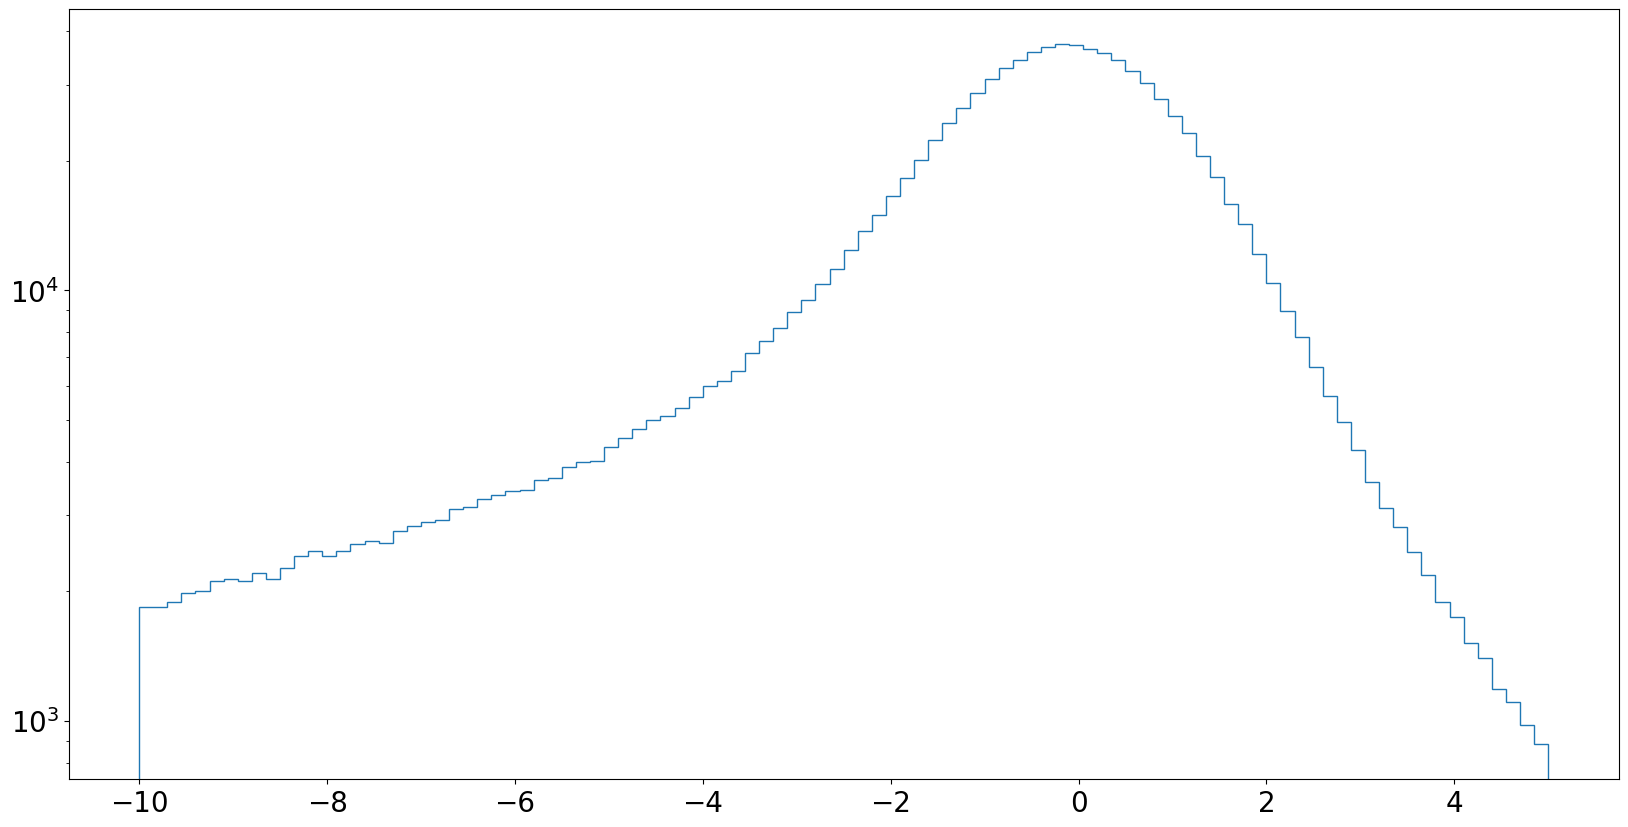

In [51]:

plt.hist(dfsep.B_Y_SEP, bins=100, range=[-10, 5], histtype='step')
plt.yscale("log")


['Normalization like', 'Double Charm', 'Bad Xc', 'Signal', 'Combinatorial', 'Tau from charm', 'others']


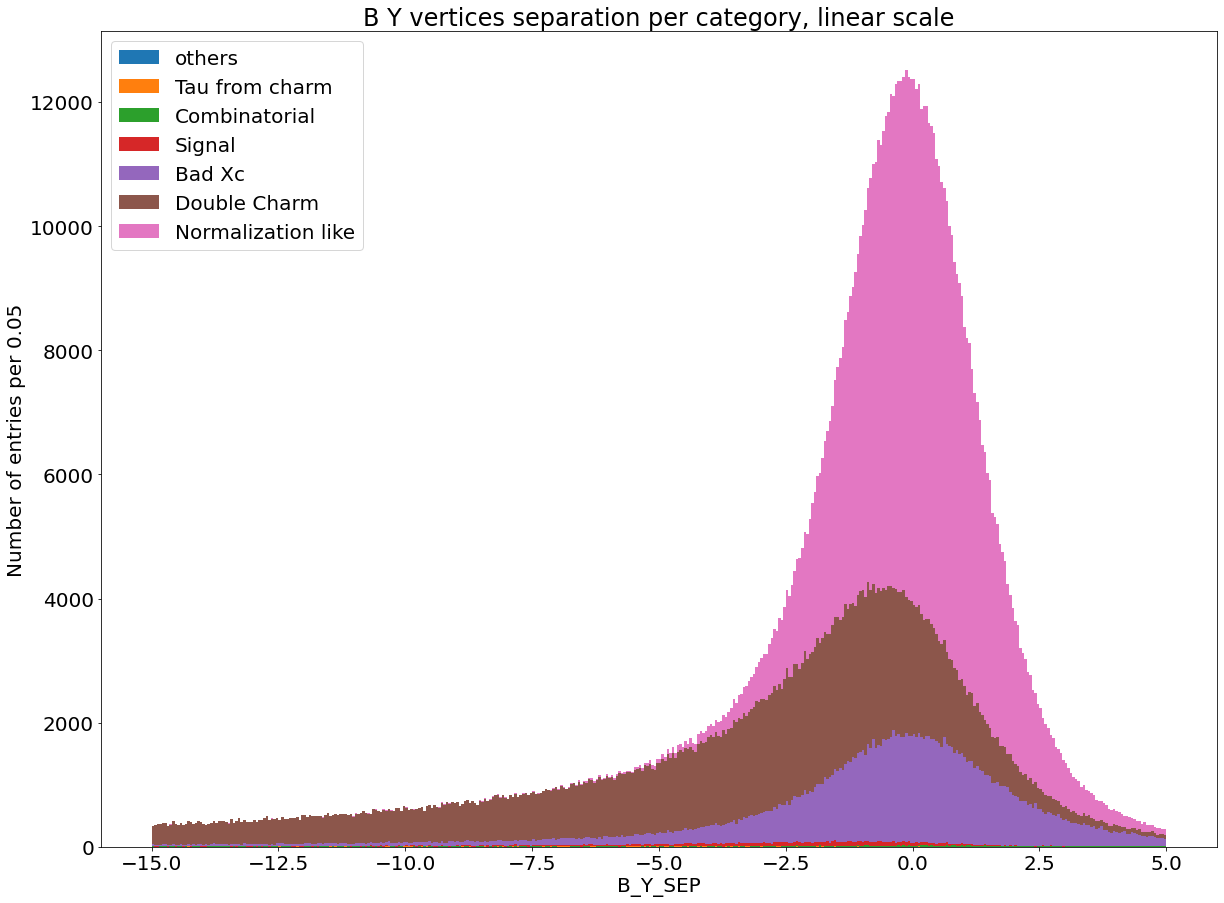

In [59]:
nbbins  = 400
myrange = [-15, 5]
categories_sorted = list(gs2.index)
print(categories_sorted)

datasets = [ dfsep.query(f"simplified_key == '{x}'").B_Y_SEP for x in reversed(categories_sorted)]
plt.hist(datasets, bins=nbbins, range=myrange, histtype='bar', label= list(reversed(categories_sorted)) , stacked=True,  fill=True, alpha=1.0)
#plt.yscale("log")
plt.xlabel("B_Y_SEP")
plt.ylabel(f"Number of entries per {(myrange[1] -myrange[0])/nbbins:.2f}" )
plt.title("B Y vertices separation per category, linear scale")
plt.legend(loc='upper left')
plt.savefig("BYsep_simplified_nocut_linear.png",  bbox_inches='tight');

['Normalization like', 'Double Charm', 'Bad Xc', 'Signal', 'Combinatorial', 'Tau from charm', 'others']


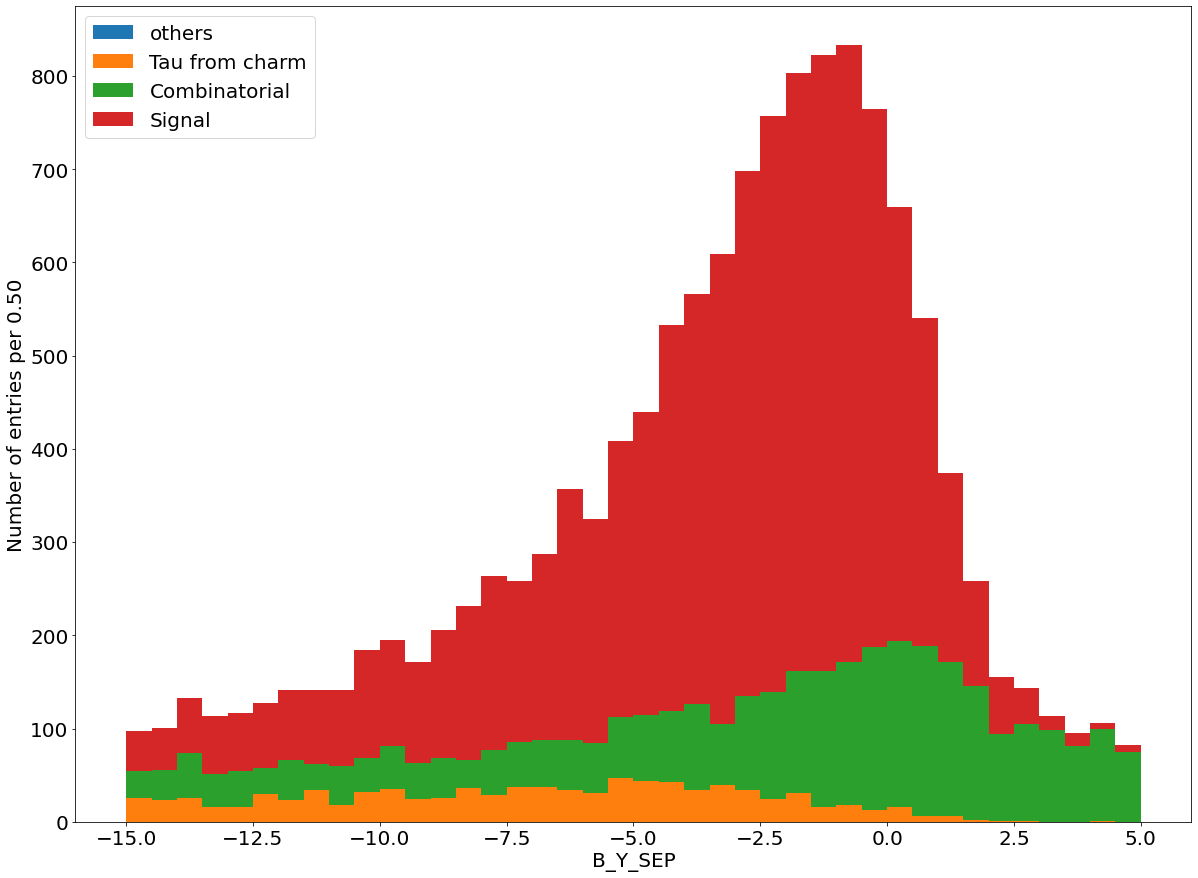

In [60]:
nbbins  = 40
myrange = [-15, 5]
categories_sorted = list(gs2.index)
print(categories_sorted)

datasets = [ dfsep.query(f"simplified_key == '{x}'").B_Y_SEP for x in reversed(categories_sorted[3:])]
plt.hist(datasets, bins=nbbins, range=myrange, histtype='bar', label= list(reversed(categories_sorted)) , stacked=True,  fill=True, alpha=1.0)
#plt.yscale("log")
plt.xlabel("B_Y_SEP")
plt.ylabel(f"Number of entries per {(myrange[1] -myrange[0])/nbbins:.2f}" )
#plt.title("B Y vertices separation per category")
plt.legend(loc='upper left')
plt.savefig("BYsep_simplified_nocut_signal_linear.png",  bbox_inches='tight');

['Normalization like', 'Double Charm', 'Bad Xc', 'Signal', 'Combinatorial', 'Tau from charm', 'others']


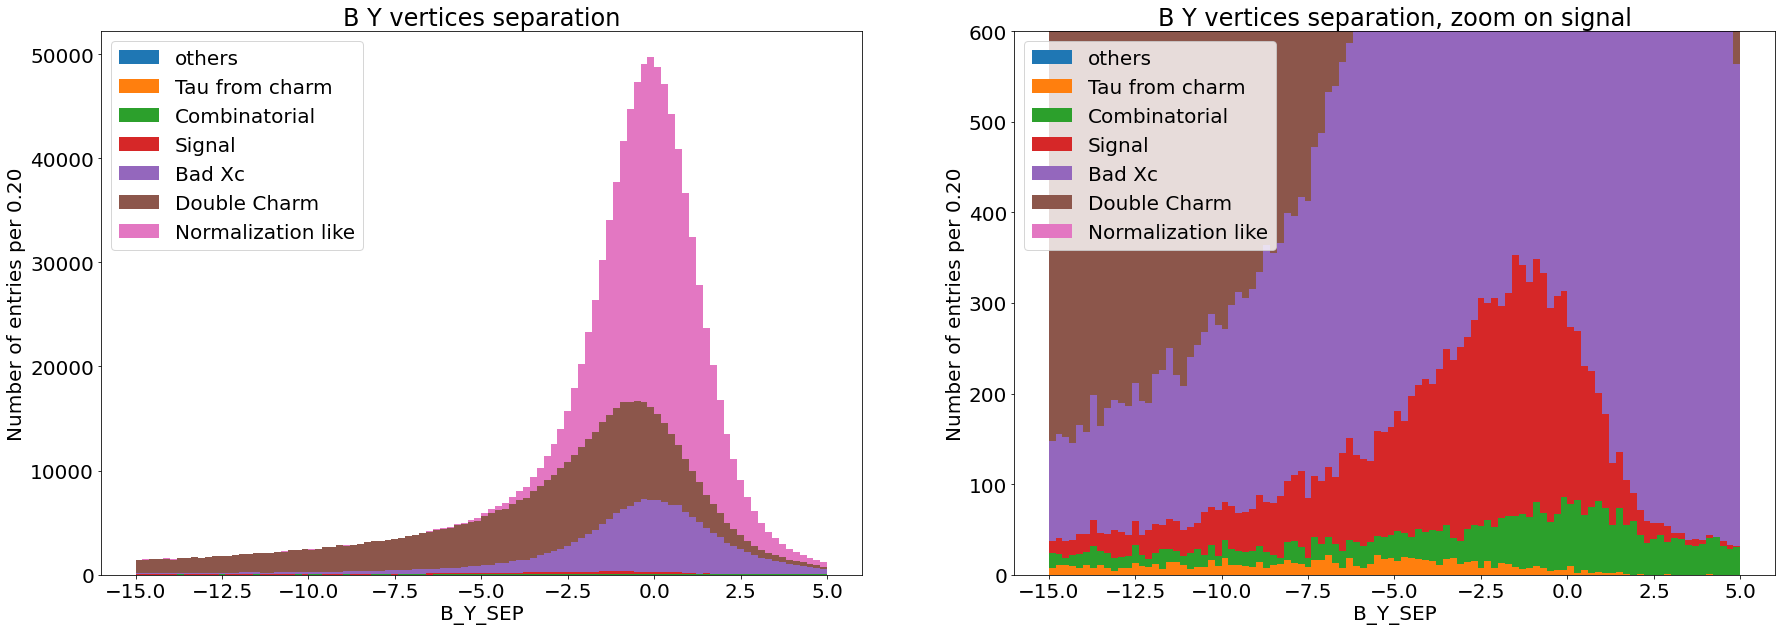

In [61]:
plt.rcParams["figure.figsize"] = (30,10)
plt.rcParams.update({'font.size': 20})
plt.subplot(121)
nbbins  = 100
myrange = [-15, 5]
categories_sorted = list(gs2.index)
print(categories_sorted)

datasets = [ dfsep.query(f"simplified_key == '{x}'").B_Y_SEP for x in reversed(categories_sorted)]
plt.hist(datasets, bins=nbbins, range=myrange, histtype='bar', label= list(reversed(categories_sorted)) , stacked=True,  fill=True, alpha=1.0)
#plt.yscale("log")
plt.xlabel("B_Y_SEP")
plt.ylabel(f"Number of entries per {(myrange[1] -myrange[0])/nbbins:.2f}" )
plt.title("B Y vertices separation")
plt.legend(loc='upper left')

plt.subplot(122)
nbbins  = 100
myrange = [-15, 5]
categories_sorted = list(gs2.index)
#datasets = [ dfsep.query(f"simplified_key == '{x}'").B_Y_SEP for x in reversed(categories_sorted[3:])]
datasets = [ dfsep.query(f"simplified_key == '{x}'").B_Y_SEP for x in reversed(categories_sorted)]
plt.hist(datasets, bins=nbbins, range=myrange, histtype='bar', label= list(reversed(categories_sorted)) , stacked=True,  fill=True, alpha=1.0)
plt.ylim([0, 600])
#plt.yscale("log")
plt.xlabel("B_Y_SEP")
plt.ylabel(f"Number of entries per {(myrange[1] -myrange[0])/nbbins:.2f}" )
plt.title("B Y vertices separation, zoom on signal")
plt.legend(loc='upper left')
plt.savefig("BYsep_simplified_nocut_linear.png",  bbox_inches='tight');


['Normalization like', 'Double Charm', 'Bad Xc', 'Signal', 'Combinatorial', 'Tau from charm', 'others']


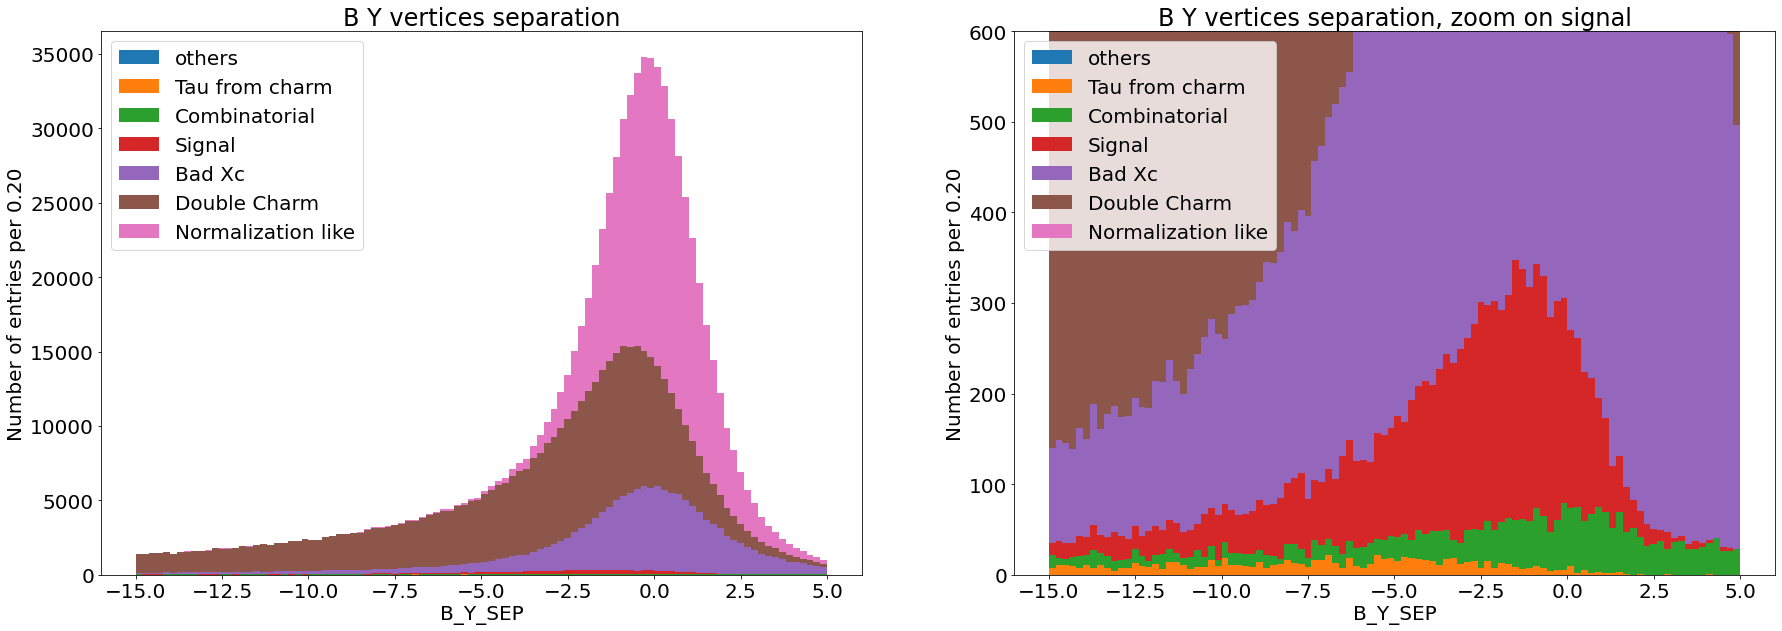

In [62]:
plt.rcParams["figure.figsize"] = (30,10)
plt.rcParams.update({'font.size': 20})
plt.subplot(121)
nbbins  = 100
myrange = [-15, 5]
categories_sorted = list(gs2.index)
print(categories_sorted)

mydf = dfsep.query("B_M < 5000")

datasets = [ mydf.query(f"simplified_key == '{x}'").B_Y_SEP for x in reversed(categories_sorted)]
plt.hist(datasets, bins=nbbins, range=myrange, histtype='bar', label= list(reversed(categories_sorted)) , stacked=True,  fill=True, alpha=1.0)
#plt.yscale("log")
plt.xlabel("B_Y_SEP")
plt.ylabel(f"Number of entries per {(myrange[1] -myrange[0])/nbbins:.2f}" )
plt.title("B Y vertices separation")
plt.legend(loc='upper left')

plt.subplot(122)
nbbins  = 100
myrange = [-15, 5]
categories_sorted = list(gs2.index)
datasets = [ mydf.query(f"simplified_key == '{x}'").B_Y_SEP for x in reversed(categories_sorted)]
plt.hist(datasets, bins=nbbins, range=myrange, histtype='bar', label= list(reversed(categories_sorted)) , stacked=True,  fill=True, alpha=1.0)
plt.ylim([0, 600])
#plt.yscale("log")
plt.xlabel("B_Y_SEP")
plt.ylabel(f"Number of entries per {(myrange[1] -myrange[0])/nbbins:.2f}" )
plt.title("B Y vertices separation, zoom on signal")
plt.legend(loc='upper left')
plt.savefig("BYsep_simplified_masscut_linear.png",  bbox_inches='tight');


['others', 'Tau from charm', 'Combinatorial', 'Signal', 'Bad Xc', 'Double Charm', 'Normalization like']
[11, 2, 9, 4, 12, 1, 13, 0, 10, 3, 8, 5, 7, 6]
['Normalization like - no B mass cut', 'Double Charm - no B mass cut', 'Bad Xc - no B mass cut', 'Signal - no B mass cut', 'Combinatorial - no B mass cut', 'Tau from charm - no B mass cut', 'others - no B mass cut', 'others', 'Tau from charm', 'Combinatorial', 'Signal', 'Bad Xc', 'Double Charm', 'Normalization like']


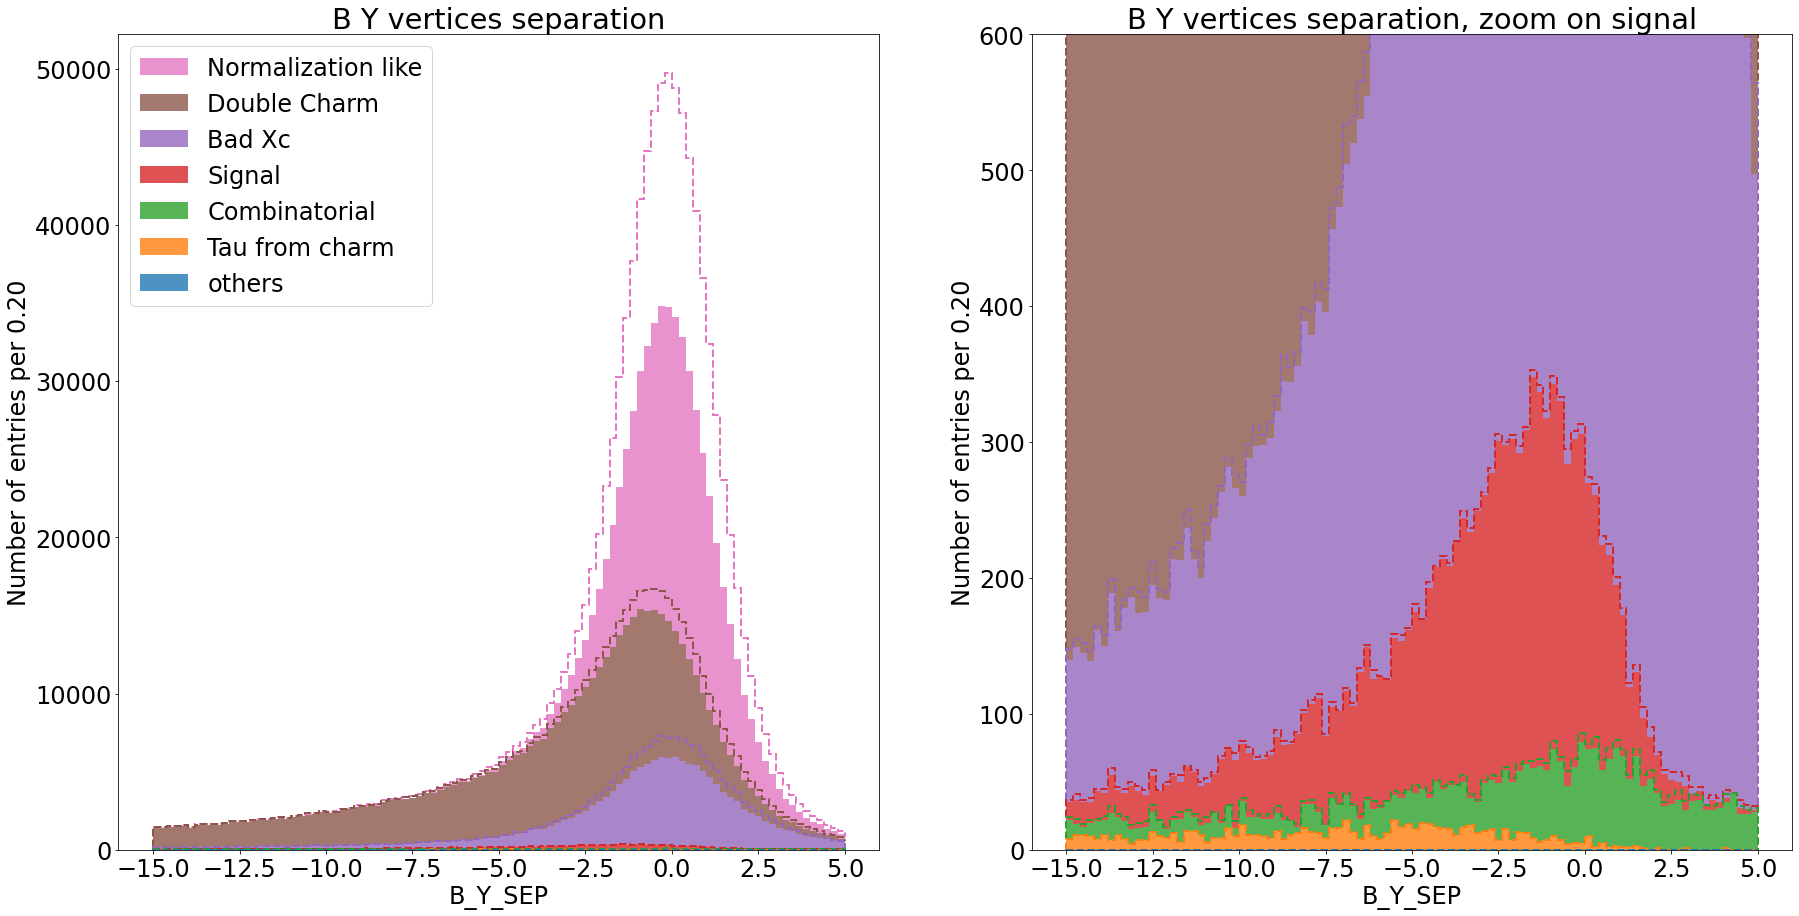

In [83]:
plt.rcParams["figure.figsize"] = (30,15)
plt.rcParams.update({'font.size': 24})
prop_cycle = plt.rcParams['axes.prop_cycle']
plt.rc('axes', prop_cycle=prop_cycle[0:7])

plt.subplot(121)
nbbins  = 100
myrange = [-15, 5]
categories_sorted = list(gs2.index)
rev_categories_sorted = list(reversed(categories_sorted))
print(rev_categories_sorted)
mydf = dfsep.query("B_M < 5000")
alpha = 0.8

datasets_nocut = [ dfsep.query(f"simplified_key == '{x}'").B_Y_SEP for x in rev_categories_sorted]
datasets = [ mydf.query(f"simplified_key == '{x}'").B_Y_SEP for x in rev_categories_sorted]

plt.hist(datasets_nocut, bins=nbbins, range=myrange, histtype='step', label=[ c + " - no B mass cut" for c in rev_categories_sorted] , stacked=True,  fill=False, alpha=1.0, linestyle='--', linewidth=2)
plt.hist(datasets, bins=nbbins, range=myrange, histtype='bar', label=rev_categories_sorted , stacked=True,  fill=True, alpha=alpha)

handles, labels = plt.gca().get_legend_handles_labels()
def filter_legend():
    """ Gets the correct handles and labels to keep only the needed ones """
    plot_labels = categories_sorted
    plot_handles = [ handles[labels.index(c)] for c in plot_labels ]
    return plot_handles, plot_labels
    
legend_order = [i[0] for i in sorted(enumerate(labels), key=lambda x:x[1])]
print(legend_order)

print(labels)
#plt.yscale("log")
plt.xlabel("B_Y_SEP")
plt.ylabel(f"Number of entries per {(myrange[1] -myrange[0])/nbbins:.2f}" )
plt.title("B Y vertices separation")
#plt.legend([handles[i] for i in legend_order], [labels[i] for i in legend_order], loc='upper left')
plt.legend(*filter_legend(), loc='upper left')

plt.subplot(122)
nbbins  = 100
myrange = [-15, 5]
# categories_sorted = list(gs2.index)
# datasets = [ mydf.query(f"simplified_key == '{x}'").B_Y_SEP for x in rev_categories_sorted]

plt.hist(datasets_nocut, bins=nbbins, range=myrange, histtype='step', label=[ c + " - no B mass cut" for c in rev_categories_sorted] , stacked=True,  fill=False, alpha=1.0, linestyle='--', linewidth=2)
plt.hist(datasets, bins=nbbins, range=myrange, histtype='bar', label= rev_categories_sorted , stacked=True,  fill=True, alpha=alpha)
plt.ylim([0, 600])
#plt.yscale("log")
plt.xlabel("B_Y_SEP")
plt.ylabel(f"Number of entries per {(myrange[1] -myrange[0])/nbbins:.2f}" )
plt.title("B Y vertices separation, zoom on signal")
#plt.legend([handles[i] for i in legend_order], [labels[i] for i in legend_order], loc='upper left')
plt.savefig("BYsep_simplified_masscut_linear.png",  bbox_inches='tight');


In [84]:
#prop_cycle = plt.rcParams['axes.prop_cycle']
#prop_cycle

['Normalization like', 'Double Charm', 'Bad Xc', 'Signal', 'Combinatorial', 'Tau from charm', 'others']


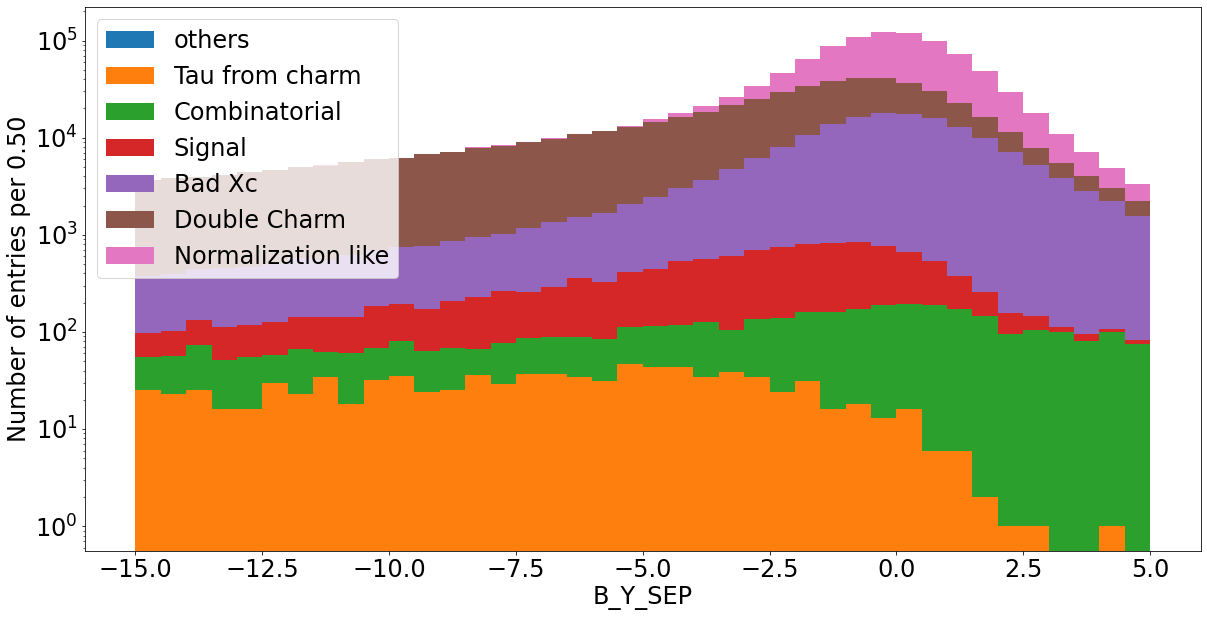

In [85]:
plt.rcParams["figure.figsize"] = (20,10)
nbbins  = 40
myrange = [-15, 5]
categories_sorted = list(gs2.index)
print(categories_sorted)

datasets = [ dfsep.query(f"simplified_key == '{x}'").B_Y_SEP for x in reversed(categories_sorted)]
plt.hist(datasets, bins=nbbins, range=myrange, histtype='bar', label= list(reversed(categories_sorted)) , stacked=True,  fill=True, alpha=1.0)
plt.yscale("log")
plt.xlabel("B_Y_SEP")
plt.ylabel(f"Number of entries per {(myrange[1] -myrange[0])/nbbins:.2f}" )
#plt.title("B Y vertices separation per category")
plt.legend(loc='upper left')
plt.savefig("BYsep_simplified_nocut_log.png",  bbox_inches='tight');

['Xc_signal_Ypis_B_vertex_fromBs', 'Xc_background', 'Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB', 'Xc_signal_Ypis_displaced_fromBs_fromDs', 'Xc_signal_Ypis_displaced_fromB0_fromDp', 'Xc_signal_Ypis_nomatch_doubleCharm', 'Xc_signal_Ypis_nomatch_Prompt', 'Xc_signal_Ypis_displaced_fromBp_fromD0', 'Xc_signal_Ypis_displaced_fromLambdab_fromLambdac', 'Xc_signal_Ypis_diffVertex_doubleCharm_TwoFromB', 'Xc_signal_Ypis_displaced_fromBs_fromDp', 'Xc_signal_Ypis_diffVertex_CharmStrange', 'Xc_signal_Ypis_B_vertex_fromOtherB', 'Xc_signal_Ypis_diffVertex_normlike', 'Xc_signal_Ypis_displaced_fromBs_fromTau', 'Xc_signal_Ypis_displaced_fromBp_fromDp', 'Xc_signal_Ypis_diffVertex_doubleCharm', 'Xc_signal_Ypis_displaced_fromB0_fromD0', 'Xc_signal_Ypis_displaced_fromB0_fromDs', 'Xc_signal_Ypis_diffAncestorYXc', 'Xc_signal_Ypis_nomatch_charmStrange', 'Xc_signal_Ypis_diffVertex_SomeFromPV', 'Xc_signal_Ypis_displaced_fromBs_fromD0', 'Xc_signal_Ypis_displaced_fromBp_fromDs', 'others', 'Xc_signal_Ypis_displa

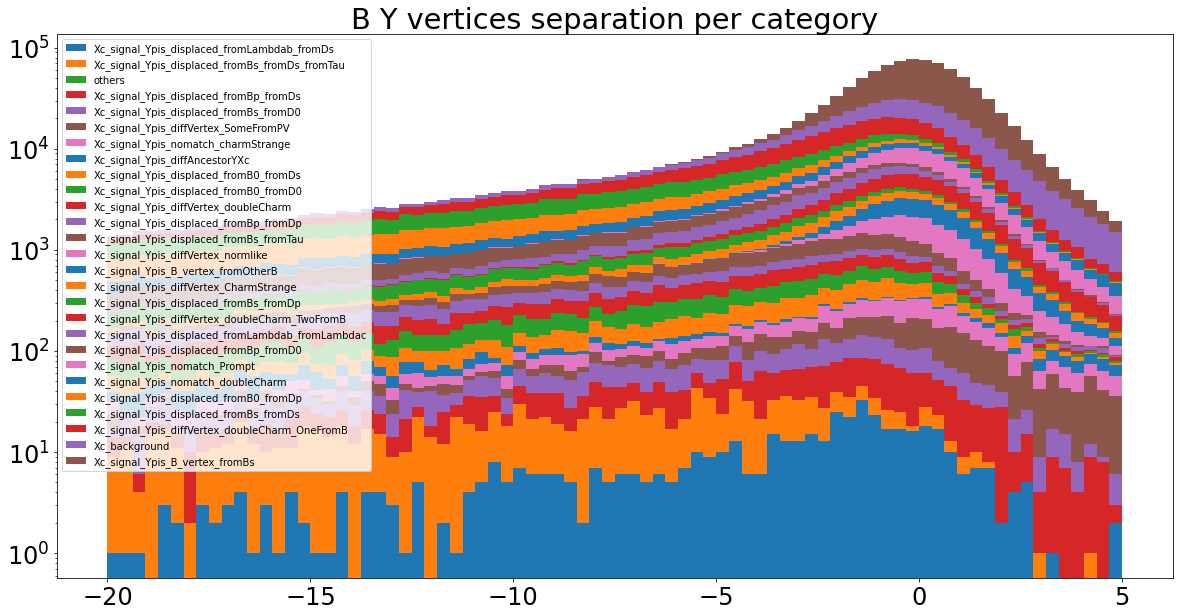

In [86]:
nbbins  = 80
myrange = [-20, 5]
categories_sorted = list(g2.index)
print(categories_sorted)


datasets = [ dfsep.query(f"key == '{x}'").B_Y_SEP for x in reversed(categories_sorted)]
plt.hist(datasets, bins=nbbins, range=myrange, histtype='bar', label= list(reversed(categories_sorted)) , stacked=True,  fill=True)
plt.yscale("log")
plt.title("B Y vertices separation per category")
plt.legend(loc='upper left', fontsize=10)
plt.savefig("BYsep_detailed_no_cut.png",  bbox_inches='tight');

# Establishing the cut

In [87]:
#if not os.path.exists("temp.root"):
#    rdf.Snapshot("DecayTree", "temp.root", [ "category", "simplified", "B_M", "B_Y_SEP", "Xc_signal_Ypis_displaced_fromBs_fromTau", "fromY_from_B_vertex"])
# rdf1 = ROOT.RDataFrame("DecayTree", "temp.root")
# rdf2 = rdf.Filter("B_M < 5000")


In [88]:
#list(rdf.GetColumnNames())

In [90]:
import math
def plot_cut_background_fromB_vertex(cuts, name):
    rdf1 = ROOT.RDataFrame("DecayTree", "temp.root")
    rdf2 = rdf1.Filter("B_M < 5000")
    print("Evaluating the cut")
    foms = []
    foms_noBcut = []
    for cutval in cuts:
        res = rdf1.Filter(f"B_Y_SEP < {cutval}", "sepcut").Filter("Xc_signal_Ypis_displaced_fromBs_fromTau == 1", "signal")
        r = res.Report().GetValue()
        print(f"=== cut: B_Y_SEP < {cutval}")
        r.Print()
        c = r['signal']
        signal_count = c.GetPass()

        resfromBvtx = rdf1.Filter(f"B_Y_SEP < {cutval}", "sepcut").Filter("fromY_from_B_vertex", "bvtx")
        r = resfromBvtx.Report().GetValue()
        r.Print()
        c = r['bvtx']
        background_count = c.GetPass()
        fom = signal_count/ math.sqrt(signal_count + background_count)
        foms_noBcut.append(fom)
        print(f"FOM: %s", fom)


    print("Evaluating the cuts with the B_M cut on the dataset")
    for cutval in cuts:
        res = rdf2.Filter(f"B_Y_SEP < {cutval}", "sepcut").Filter("Xc_signal_Ypis_displaced_fromBs_fromTau == 1", "signal")
        r = res.Report().GetValue()
        print(f"=== cut: B_Y_SEP < {cutval}")
        r.Print()
        c = r['signal']
        signal_count = c.GetPass()
        
        resfromBvtx = rdf2.Filter(f"B_Y_SEP < {cutval}", "sepcut").Filter("fromY_from_B_vertex", "bvtx")
        r = resfromBvtx.Report().GetValue()
        r.Print()
        c = r['bvtx']
        background_count = c.GetPass()

        fom = signal_count/ math.sqrt(signal_count + background_count)
        foms.append(fom)
        print("FOM: %s", fom)
    return foms, foms_noBcut




#cuts = np.arange(-7, 5, 0.1)
cuts = np.arange(-7, 5, 0.1)
foms, foms_noBcut = plot_cut_background_fromB_vertex(cuts, "B_Y_cut_FOM.png")


Evaluating the cut
=== cut: B_Y_SEP < -7.0
FOM: %s 44.12099046402336
=== cut: B_Y_SEP < -6.9
FOM: %s 44.40522704099819
=== cut: B_Y_SEP < -6.800000000000001
FOM: %s 44.70530186847545
=== cut: B_Y_SEP < -6.700000000000001
FOM: %s 45.02054466995243
=== cut: B_Y_SEP < -6.600000000000001
FOM: %s 45.21319598202599
=== cut: B_Y_SEP < -6.500000000000002
FOM: %s 45.47185282450327
=== cut: B_Y_SEP < -6.400000000000002
FOM: %s 45.87595320199659
=== cut: B_Y_SEP < -6.3000000000000025
FOM: %s 46.31868596037378
=== cut: B_Y_SEP < -6.200000000000003
FOM: %s 46.58836324708167
=== cut: B_Y_SEP < -6.100000000000003
FOM: %s 46.822714498309594
=== cut: B_Y_SEP < -6.0000000000000036
FOM: %s 47.096883508910864
=== cut: B_Y_SEP < -5.900000000000004
FOM: %s 47.297578033366946
=== cut: B_Y_SEP < -5.800000000000004
FOM: %s 47.564820802626265
=== cut: B_Y_SEP < -5.700000000000005
FOM: %s 47.738192197365656
=== cut: B_Y_SEP < -5.600000000000005
FOM: %s 47.953516593044746
=== cut: B_Y_SEP < -5.500000000000005
FOM

FOM: %s 47.330105523745544
=== cut: B_Y_SEP < -6.200000000000003
FOM: %s 47.64443150422186
=== cut: B_Y_SEP < -6.100000000000003
FOM: %s 47.91331092113295
=== cut: B_Y_SEP < -6.0000000000000036
FOM: %s 48.23241758485891
=== cut: B_Y_SEP < -5.900000000000004
FOM: %s 48.46270086854512
=== cut: B_Y_SEP < -5.800000000000004
FOM: %s 48.80453004383156
=== cut: B_Y_SEP < -5.700000000000005
FOM: %s 49.050004206129884
=== cut: B_Y_SEP < -5.600000000000005
FOM: %s 49.30560584804499
=== cut: B_Y_SEP < -5.500000000000005
FOM: %s 49.61578225286757
=== cut: B_Y_SEP < -5.400000000000006
FOM: %s 49.966490887049346
=== cut: B_Y_SEP < -5.300000000000006
FOM: %s 50.100436405985285
=== cut: B_Y_SEP < -5.200000000000006
FOM: %s 50.32920822897642
=== cut: B_Y_SEP < -5.100000000000007
FOM: %s 50.49523870621809
=== cut: B_Y_SEP < -5.000000000000007
FOM: %s 50.57144622177842
=== cut: B_Y_SEP < -4.9000000000000075
FOM: %s 50.748017416213415
=== cut: B_Y_SEP < -4.800000000000008
FOM: %s 50.85051731002161
=== cut

In [94]:

# Result extracted 13/07/23
# forms_noBcut = [44.12099046402336, 44.40522704099819, 44.70530186847545, 45.02054466995243, 45.21319598202599, 45.47185282450327, 45.87595320199659, 46.31868596037378, 46.58836324708167, 46.822714498309594, 47.096883508910864, 47.297578033366946, 47.564820802626265, 47.738192197365656, 47.953516593044746, 48.18699373146161, 48.361077165079394, 48.36154834630648, 48.486007541438674, 48.49648778042179, 48.49293445939229, 48.535832054177284, 48.495749306107, 48.300596526831285, 48.19053679978473, 48.00919847866941, 47.97889308997967, 47.74947909472683, 47.508744153776384, 47.26862790053925, 46.98108096127891, 46.729547910804406, 46.18643919045001, 45.75765761628562, 45.24833628552375, 44.6394199925301, 44.02654298127311, 43.324837477949565, 42.364978380783896, 41.570827404195065, 40.7600379172297, 39.85672161300528, 38.79773994413378, 37.698991681464456, 36.739352343604345, 35.75744071121476, 34.800807039250046, 33.64067205469675, 32.56419191796365, 31.511034208833802, 30.528204953041417, 29.423246774523736, 28.375812609806022, 27.36629514729178, 26.417250675464153, 25.630039787283806, 24.732850127292675, 23.89960040171099, 23.168341616186165, 22.416083902220212, 21.747246159402, 21.10584852682227, 20.513060040526174, 19.937469318678172, 19.42828661337145, 18.9446941401733, 18.460271783030645, 18.041631436983955, 17.653162874966092, 17.29069703049337, 16.96562459339774, 16.6430654205628, 16.366685923792765, 16.11864370415292, 15.879355036555994, 15.669371304563944, 15.473932518595067, 15.328147075151463, 15.14733192207373, 14.990427875872397, 14.87154922569411, 14.755278605917143, 14.65341696970312, 14.548043481501082, 14.457619638800722, 14.376568723613127, 14.308037370315384, 14.24766586495479, 14.188276296842002, 14.129195502957925, 14.082459168991617, 14.047428548369052, 14.006866679556216, 13.9748404482806, 13.951563484194063, 13.927985466852526, 13.906799544481133, 13.883677126337338, 13.871684953776105, 13.859989377850912, 13.85510760914069, 13.84547568718415, 13.83086064805875, 13.820361160482287, 13.814418350663596, 13.80873020158972, 13.800804445890686, 13.798448152168845, 13.796984706218428, 13.793303465523469, 13.790429414142547, 13.786449080548067, 13.783341932195292, 13.77887985958494, 13.775247299028212, 13.776323342949269, 13.776083329174435, 13.77643480312558, 13.777116210511332, 13.776331017272975]
# foms = [44.79930747437675, 45.1270843783796, 45.4706198653574, 45.793998652886934, 46.05023505230397, 46.39086705511615, 46.848456296859794, 47.330105523745544, 47.64443150422186, 47.91331092113295, 48.23241758485891, 48.46270086854512, 48.80453004383156, 49.050004206129884, 49.30560584804499, 49.61578225286757, 49.966490887049346, 50.100436405985285, 50.32920822897642, 50.49523870621809, 50.57144622177842, 50.748017416213415, 50.85051731002161, 50.823305095670534, 50.86936593932264, 50.84391090003074, 50.949020005021744, 50.92889264127148, 50.9136502311208, 50.82582902455747, 50.726731962144626, 50.61346003662336, 50.29343076427222, 50.1161479248783, 49.863912489677524, 49.457924564732835, 49.07352600515452, 48.62044860283864, 47.79998181789615, 47.143297675368004, 46.512094090716886, 45.726396662303124, 44.7752546400268, 43.74828628635346, 42.90377618527736, 42.05564981593568, 41.189551702374644, 40.04614807366945, 38.99709401058244, 37.90738566922174, 36.91471011197547, 35.777137707163156, 34.68701378445166, 33.586280503909, 32.56757025208286, 31.73594252264975, 30.74303381978037, 29.811897486563364, 29.010088605646594, 28.129606596098085, 27.362865428292174, 26.61347751663653, 25.92144469856038, 25.237621623909806, 24.64502747652303, 24.07352052696323, 23.492379820083404, 22.98354575260056, 22.510664188614083, 22.080769178575498, 21.68690966817875, 21.289203018021983, 20.951771682520413, 20.64505121303026, 20.350208395650974, 20.093423169381236, 19.853847798374908, 19.680936219002486, 19.455117967940588, 19.260652448153298, 19.110207006146915, 18.96465971820271, 18.8336689495845, 18.69702852620424, 18.58233929755677, 18.474695918263368, 18.38628374376762, 18.307359737426346, 18.228846242742296, 18.15064114564899, 18.087380548412426, 18.04087594316849, 17.98670876163497, 17.94166634974531, 17.90924567006053, 17.876282214087805, 17.847036367210414, 17.814180175821882, 17.796368724896684, 17.777891692019885, 17.76866328870774, 17.754152592028166, 17.733482381206883, 17.719089538543123, 17.71014780373971, 17.70111719658165, 17.689792666851677, 17.68499627552094, 17.681584665959214, 17.6765917536176, 17.67166606744171, 17.66577824930252, 17.6612915611846, 17.654186694430983, 17.64882747324544, 17.649426700574214, 17.648505713918137, 17.64859823319668, 17.64926947844988, 17.647669217135682]


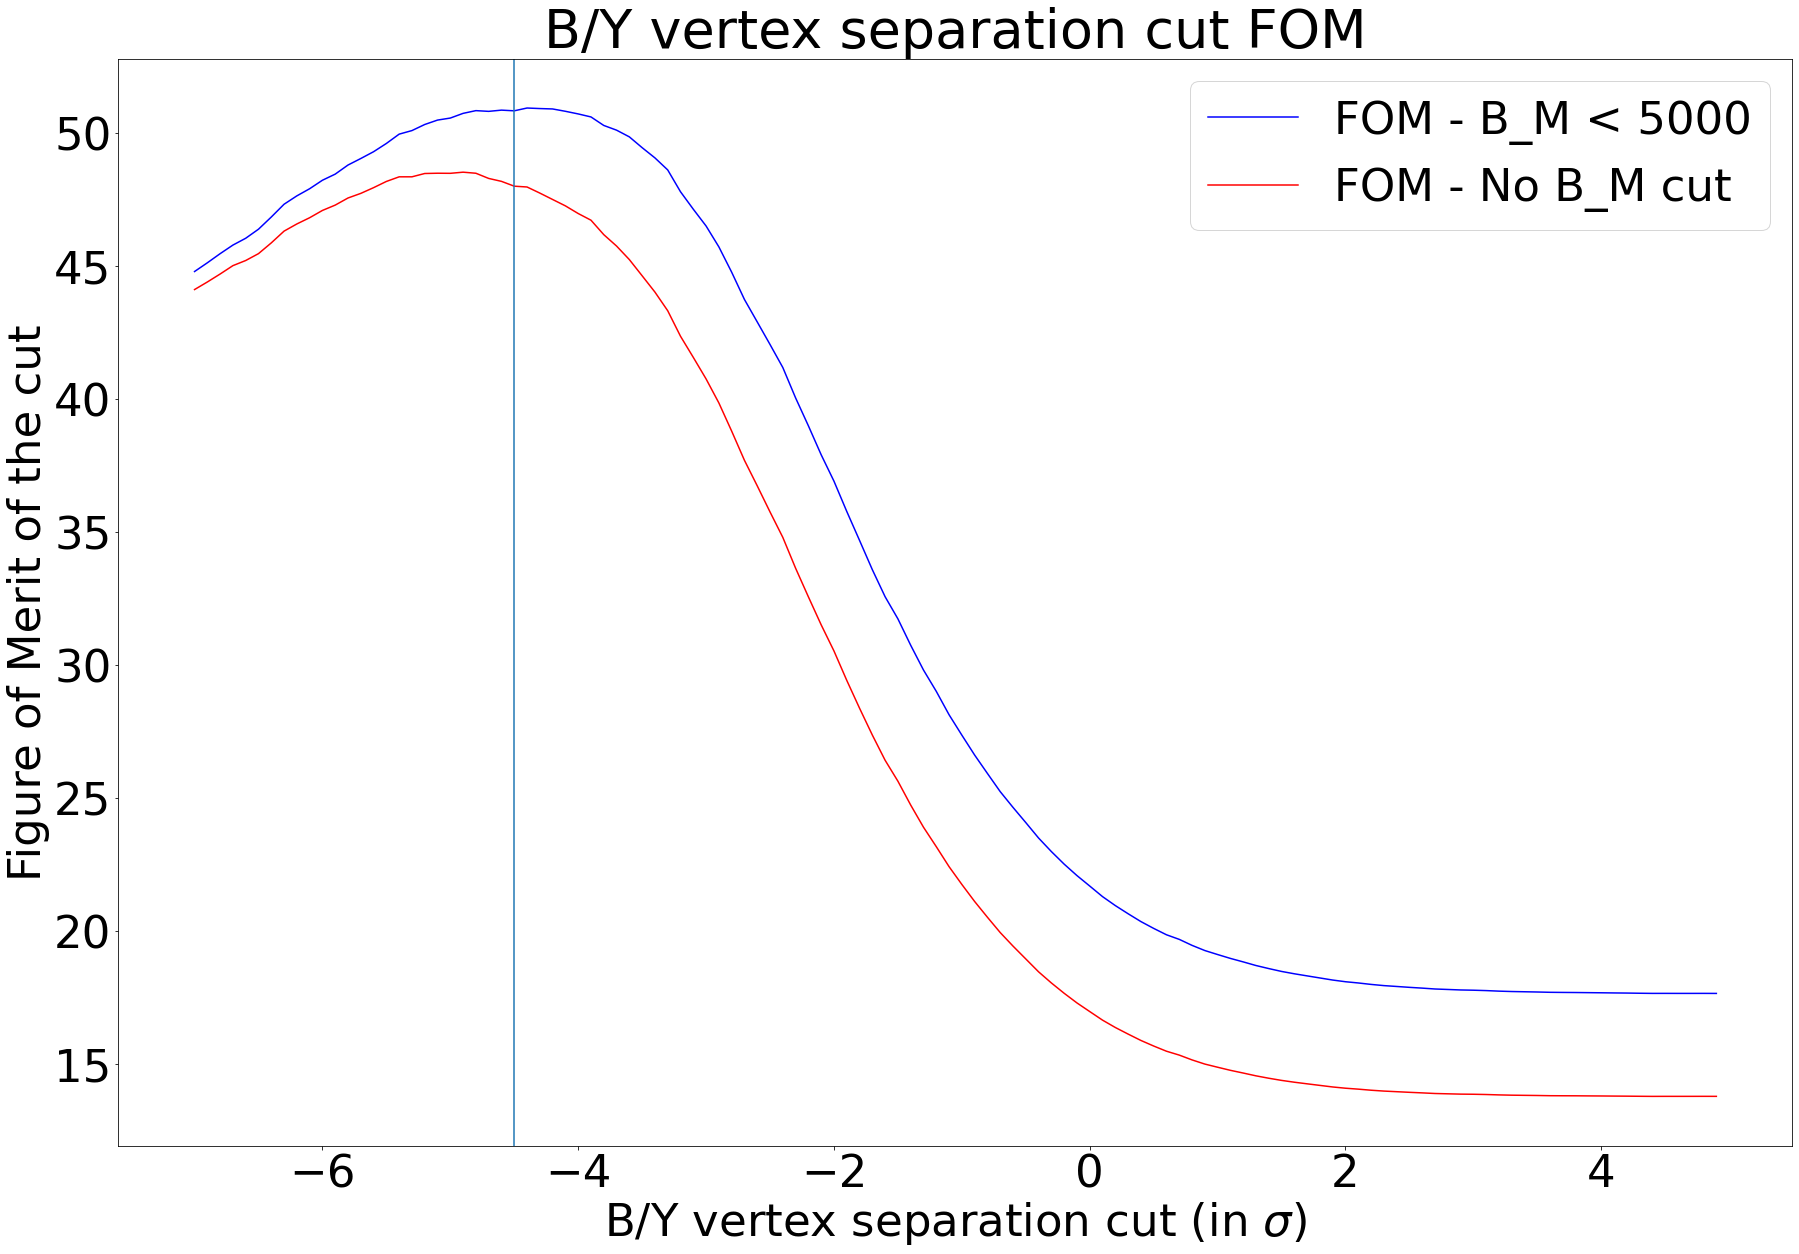

In [99]:
plt.rcParams["figure.figsize"] = (30,20)
plt.rcParams.update({'font.size': 45})
plt.figure()
plt.tight_layout()
plt.plot(cuts, foms, "-b", label="FOM - B_M < 5000")
plt.plot(cuts, foms_noBcut, "-r", label="FOM - No B_M cut")
plt.ylabel("Figure of Merit of the cut")
plt.xlabel("B/Y vertex separation cut (in $\sigma$)")
plt.legend()
plt.axvline(-4.5)
plt.title("B/Y vertex separation cut FOM")
plt.savefig("fom.png")


In [ ]:

cuts_zoom = np.arange(-6, -4, 0.02)
fom_zoom = plot_cut_background_fromB_vertex(cuts_zoom, "B_Y_cut_FOM_zoom.png")

In [ ]:
plt.figure()
plt.tight_layout()
#plt.plot(cuts, foms, "-b", label="FOM - B_M < 5000")
plt.plot(cuts_zoom, fom_zoom, "-r", label="FOM ")
plt.ylabel("Figure of Merit of the cut")
plt.xlabel("B/Y vertex separation cut (in $\sigma$)")
#plt.legend()
#plt.axvline(-4.5)
plt.title("B/Y vertex separation cut FOM")
plt.savefig("fom_zoom.png")

## Categories after B_Y_SEP cut

In [56]:
df_sep_cut

,B_M,B_Y_SEP,Xc_signal_Ypis_displaced_fromBs_fromTau,category,fromY_from_B_vertex,simplified,simplified_key,key
0,3549.868167,-42.580564,False,0,False,1001,Bad Xc,Xc_background
4,3319.233948,-25.553933,False,0,False,1001,Bad Xc,Xc_background
5,3952.608126,-10.530797,False,19,False,1004,Double Charm,Xc_signal_Ypis_displaced_fromB0_fromDp
16,3590.944305,-5.040866,False,0,False,1001,Bad Xc,Xc_background
18,3747.756129,-5.497857,False,18,False,1004,Double Charm,Xc_signal_Ypis_displaced_fromBs_fromDs
...,...,...,...,...,...,...,...,...
1207663,4027.889398,-20.939083,False,18,False,1004,Double Charm,Xc_signal_Ypis_displaced_fromBs_fromDs
1207679,4565.097589,-12.364674,False,18,False,1004,Double Charm,Xc_signal_Ypis_displaced_fromBs_fromDs
1207683,4689.555203,-29.903899,False,18,False,1004,Double Charm,Xc_signal_Ypis_displaced_fromBs_fromDs
1207692,3400.800053,-5.197422,False,7,False,1004,Double Charm,Xc_signal_Ypis_nomatch_doubleCharm


In [52]:
df_sep_cut = dfsep.query("B_M < 5000 & B_Y_SEP < -4.5")

In [53]:
gs_sep_cut = mygroupby(df_sep_cut, "simplified_key")

In [54]:
with pd.option_context("max_colwidth", 1000, 'display.precision', 2, 'float_format',  '{:,.2f}'.format):
    print(gs_sep_cut[['simplified_key', 'count', 'Percentage']].to_latex(index=None))

\begin{tabular}{lrr}
\toprule
     simplified\_key &   count &  Percentage \\
\midrule
       Double Charm &  209787 &       87.50 \\
             Bad Xc &   20923 &        8.73 \\
             Signal &    3594 &        1.50 \\
 Normalization like &    2090 &        0.87 \\
      Combinatorial &    1985 &        0.83 \\
     Tau from charm &    1150 &        0.48 \\
    Other displaced &     178 &        0.07 \\
      Uncategorized &      51 &        0.02 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_250067/3573765326.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(gs_sep_cut[['simplified_key', 'count', 'Percentage']].to_latex(index=None))


In [55]:
print(gs_sep_cut[['simplified_key', 'count', 'Percentage']].to_markdown(index=None))

| simplified_key     |   count |   Percentage |
|:-------------------|--------:|-------------:|
| Double Charm       |  209787 |   87.4995    |
| Bad Xc             |   20923 |    8.72672   |
| Signal             |    3594 |    1.49901   |
| Normalization like |    2090 |    0.871712  |
| Combinatorial      |    1985 |    0.827918  |
| Tau from charm     |    1150 |    0.47965   |
| Other displaced    |     178 |    0.0742415 |
| Uncategorized      |      51 |    0.0212714 |


In [105]:
g_sep_cut = mygroupby(df_sep_cut, "key")

In [106]:
with pd.option_context("max_colwidth", 1000, 'display.precision', 2, 'float_format',  '{:,.3f}'.format):
    print(g_sep_cut[['key', 'count', 'Percentage']].to_latex(index=None))

\begin{tabular}{lrr}
\toprule
                                                 key &  count &  Percentage \\
\midrule
              Xc\_signal\_Ypis\_displaced\_fromBs\_fromDs &  48572 &      20.259 \\
              Xc\_signal\_Ypis\_displaced\_fromB0\_fromDp &  48126 &      20.073 \\
      Xc\_signal\_Ypis\_diffVertex\_doubleCharm\_OneFromB &  35855 &      14.955 \\
                                       Xc\_background &  20923 &       8.727 \\
              Xc\_signal\_Ypis\_displaced\_fromBp\_fromD0 &  19002 &       7.925 \\
                  Xc\_signal\_Ypis\_nomatch\_doubleCharm &  16249 &       6.777 \\
              Xc\_signal\_Ypis\_displaced\_fromBs\_fromDp &  10955 &       4.569 \\
    Xc\_signal\_Ypis\_displaced\_fromLambdab\_fromLambdac &   6516 &       2.718 \\
              Xc\_signal\_Ypis\_displaced\_fromBp\_fromDp &   5973 &       2.491 \\
               Xc\_signal\_Ypis\_diffVertex\_doubleCharm &   4751 &       1.982 \\
              Xc\_signal\_Ypis\_displaced\_fromB

In [107]:
print(g_sep_cut[['key', 'count', 'Percentage']].to_markdown(index=None))

| key                                                 |   count |   Percentage |
|:----------------------------------------------------|--------:|-------------:|
| Xc_signal_Ypis_displaced_fromBs_fromDs              |   48572 | 20.2588      |
| Xc_signal_Ypis_displaced_fromB0_fromDp              |   48126 | 20.0727      |
| Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB      |   35855 | 14.9547      |
| Xc_background                                       |   20923 |  8.72672     |
| Xc_signal_Ypis_displaced_fromBp_fromD0              |   19002 |  7.92549     |
| Xc_signal_Ypis_nomatch_doubleCharm                  |   16249 |  6.77725     |
| Xc_signal_Ypis_displaced_fromBs_fromDp              |   10955 |  4.56919     |
| Xc_signal_Ypis_displaced_fromLambdab_fromLambdac    |    6516 |  2.71774     |
| Xc_signal_Ypis_displaced_fromBp_fromDp              |    5973 |  2.49126     |
| Xc_signal_Ypis_diffVertex_doubleCharm               |    4751 |  1.98158     |
| Xc_signal_Ypis_displaced_f

## Checking the effect of the cut category by category

In [108]:
g_sep_cut

,key,count,Percentage,cumulative %
0,Xc_signal_Ypis_displaced_fromBs_fromDs,48572,20.258761,20.258761
1,Xc_signal_Ypis_displaced_fromB0_fromDp,48126,20.072740,40.331501
2,Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB,35855,14.954663,55.286164
3,Xc_background,20923,8.726716,64.012880
4,Xc_signal_Ypis_displaced_fromBp_fromD0,19002,7.925492,71.938371
5,Xc_signal_Ypis_nomatch_doubleCharm,16249,6.777250,78.715622
6,Xc_signal_Ypis_displaced_fromBs_fromDp,10955,4.569191,83.284812
7,Xc_signal_Ypis_displaced_fromLambdab_fromLambdac,6516,2.717740,86.002553
8,Xc_signal_Ypis_displaced_fromBp_fromDp,5973,2.491262,88.493815
9,Xc_signal_Ypis_diffVertex_doubleCharm,4751,1.981581,90.475396


In [109]:
gs_sep_cut.set_index('simplified_key', inplace=True)

In [110]:
gs_sep_cut

,count,Percentage,cumulative %
simplified_key,,,
Double Charm,209787,87.499479,87.499479
Bad Xc,20923,8.726716,96.226195
Signal,3594,1.499012,97.725206
Normalization like,2090,0.871712,98.596919
Combinatorial,1985,0.827918,99.424837
Tau from charm,1150,0.479650,99.904487
Other displaced,178,0.074242,99.978729
Uncategorized,51,0.021271,100.000000


In [111]:
gs.set_index('simplified_key', inplace=True)

In [112]:
gs

,count,Percentage,cumulative %,Category
simplified_key,,,,
Normalization like,541243,44.816125,44.816125,Normalization like
Double Charm,464918,38.496245,83.312371,Double Charm
Bad Xc,183031,15.155374,98.467745,Bad Xc
Signal,9966,0.825207,99.292952,Signal
Combinatorial,6657,0.551214,99.844166,Combinatorial
Tau from charm,1441,0.119318,99.963484,Tau from charm
Other displaced,345,0.028567,99.992051,others
Uncategorized,96,0.007949,100.000000,others


In [113]:
evo = pd.merge(gs[['count']], gs_sep_cut[['count']],  left_index=True, right_index=True, suffixes=["_nocut", "_withcut"])

In [114]:
evo

,count_nocut,count_withcut
simplified_key,,
Normalization like,541243,2090
Double Charm,464918,209787
Bad Xc,183031,20923
Signal,9966,3594
Combinatorial,6657,1985
Tau from charm,1441,1150
Other displaced,345,178
Uncategorized,96,51


In [115]:
evo["Category"] = gs.apply(lambda row: row.name if row["count"] > 400 else "others", axis=1)
evo2 = evo.groupby("Category").sum()
evo2 = evo2.sort_values([ 'count_nocut'], ascending=False)
evo2["count_evolution (%)"] = -100 * (evo2["count_nocut"] - evo2["count_withcut"]) / evo2["count_nocut"]
evo2

,count_nocut,count_withcut,count_evolution (%)
Category,,,
Normalization like,541243,2090,-99.613852
Double Charm,464918,209787,-54.876559
Bad Xc,183031,20923,-88.568603
Signal,9966,3594,-63.937387
Combinatorial,6657,1985,-70.181764
Tau from charm,1441,1150,-20.194310
others,441,229,-48.072562


In [116]:
with pd.option_context("max_colwidth", 1000, 'display.precision', 2):
    print(evo2.to_latex())

\begin{tabular}{lrrr}
\toprule
{} &  count\_nocut &  count\_withcut &  count\_evolution (\%) \\
Category           &              &                &                      \\
\midrule
Normalization like &       541243 &           2090 &               -99.61 \\
Double Charm       &       464918 &         209787 &               -54.88 \\
Bad Xc             &       183031 &          20923 &               -88.57 \\
Signal             &         9966 &           3594 &               -63.94 \\
Combinatorial      &         6657 &           1985 &               -70.18 \\
Tau from charm     &         1441 &           1150 &               -20.19 \\
others             &          441 &            229 &               -48.07 \\
\bottomrule
\end{tabular}



## Checking the effect of the cuts on double charm background

In [117]:
[ c for c in f.categories.keys() if "Dp" in str(c) ]

['Xc_signal_Ypis_displaced_fromB0_fromDp',
 'Xc_signal_Ypis_displaced_fromBs_fromDp',
 'Xc_signal_Ypis_displaced_fromBp_fromDp',
 'Xc_signal_Ypis_displaced_fromLambdab_fromDp',
 'Xc_signal_Ypis_displaced_fromB0_fromDp_fromTau',
 'Xc_signal_Ypis_displaced_fromBs_fromDp_fromTau',
 'Xc_signal_Ypis_displaced_fromBp_fromDp_fromTau']

# Kept for doc only, to be checked

# B_Y_SEP 

list(g_sep_cut.index)

nbbins  = 300
myrange = [-20, -4]
categories_sorted = list(g_sep_cut.index)#list(g_sep_cut['key'])

#print(categories_sorted)
#print([ f"key = '{x}'" for x in reversed(categories_sorted)])
#print([ f"key == '{x}'" for x in reversed(categories_sorted)])

datasets = [ df_sep_cut.query(f"key == '{x}'").B_Y_SEP for x in reversed(categories_sorted)]
plt.hist(datasets, bins=nbbins, range=myrange, histtype='step', label= list(reversed(categories_sorted)) , stacked=True,  fill=True)
#plt.yscale("log")
plt.title("B Y vertices separation per category")
plt.legend(loc='upper left')
plt.savefig("BYsep_after_cut.png",  bbox_inches='tight');

# Effect of B_Y_SEP < -4.5 on double charm background

df

nbbins  = 300
myrange = [-50, 5]
#categories_sorted = list(g_sep_cut['key'])
categories_sorted = ['doubleCharm']

datasets = [ df.query(f"simplified_key == '{x}'").B_Y_SEP for x in reversed(categories_sorted)]
plt.hist(datasets, bins=nbbins, range=myrange, histtype='step', label= list(reversed(categories_sorted)) , stacked=False,  fill=False)
#plt.yscale("log")
plt.title("B Y vertices separation per category")
plt.legend(loc='upper left')
plt.savefig("BYsep_signal_and_double_charm_linear",  bbox_inches='tight');

nbbins  = 300
myrange = [-50, 5]
#categories_sorted = list(g_sep_cut['key'])
categories_sorted = ['doubleCharm']

datasets = [ df.query(f"simplified_key == '{x}'").B_Y_SEP for x in reversed(categories_sorted)]
plt.hist(datasets, bins=nbbins, range=myrange, histtype='step', label= list(reversed(categories_sorted)) , stacked=False,  fill=False)
plt.yscale("log")
plt.title("B Y vertices separation per category")
plt.legend(loc='upper left')
plt.savefig("BYsep_signal_and_double_charm_log",  bbox_inches='tight');

# Effect of B_Y_SEP < -4.5 on Xc_Background

dfbkg = df[df['key'] == 'Xc_background']

plt.hist(df['B_MM'], bins=200, range=[0, 6000], histtype='step');

plt.hist(df['Y_MM'], bins=200, range=[0, 3500], histtype='step');

nbbins  = 200
myrange = [-20, 20]

dfXc_nok = df.query("key == 'Xc_background'")
dfXc_ok = df.query("key != 'Xc_background'")

datasets = [ df.B_Y_SEP for df in [ dfXc_ok, dfXc_nok ]]
plt.hist(datasets, bins=nbbins, range=myrange, histtype='step', label=[ "Xc OK", "Xc Background" ], density=True)
#plt.yscale("log")
plt.title("B_Y_SEP normalized histograms for Xc ok/background")
plt.legend(loc='upper left')
plt.savefig("BYsep_Xc_background",  bbox_inches='tight');

dfXc_ok['B_Y_SEP'].skew()

dfXc_nok['B_Y_SEP'].skew()